In [8]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [13]:
# Paramaters
windows = 252
K = 10  # fixed number of PCA factors for first draft

$JNPR: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found
$ZI: possibly delisted; no timezone found

3 Failed downloads:
['JNPR', 'ANSS', 'ZI']: possibly delisted; no timezone found


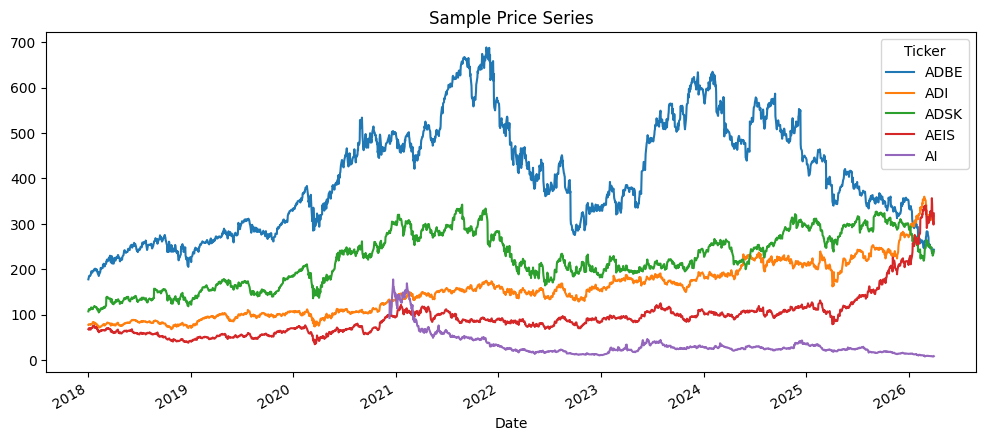

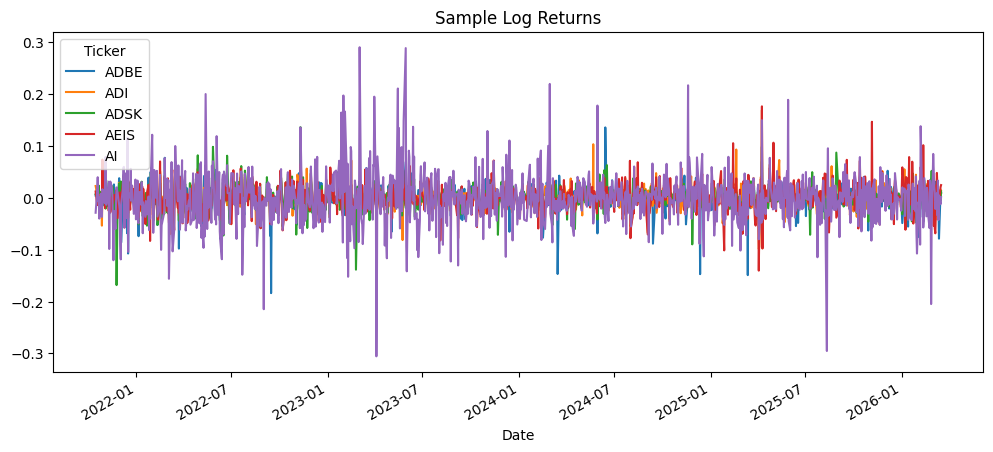

In [10]:
start_date = "2018-01-01"  # Start data
end_date = None # To this day

raw = yf.download(
    tickers=universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

prices = raw["Close"].copy()


# sort dates and columns
prices = prices.sort_index()
prices = prices.reindex(sorted(prices.columns), axis=1)

# drop columns that are completely missing
prices = prices.dropna(axis=1, how="all")
min_obs = 252
mask = prices.notna().sum() >= min_obs
prices = prices.loc[:, mask]


log_prices = np.log(prices)
returns = log_prices.diff().dropna()

sample_stocks = returns.columns[:5]

# Plot A: prices
prices[sample_stocks].plot(figsize=(12,5), title="Sample Price Series")
plt.show()

# Plot B: log returns
returns[sample_stocks].plot(figsize=(12,5), title="Sample Log Returns")
plt.show()

returns_clean shape: (1108, 99)
Any NaNs left?: False
Sample end date: 2026-03-17 00:00:00
R_t shape: (252, 99)
Any NaNs in R_t?: False


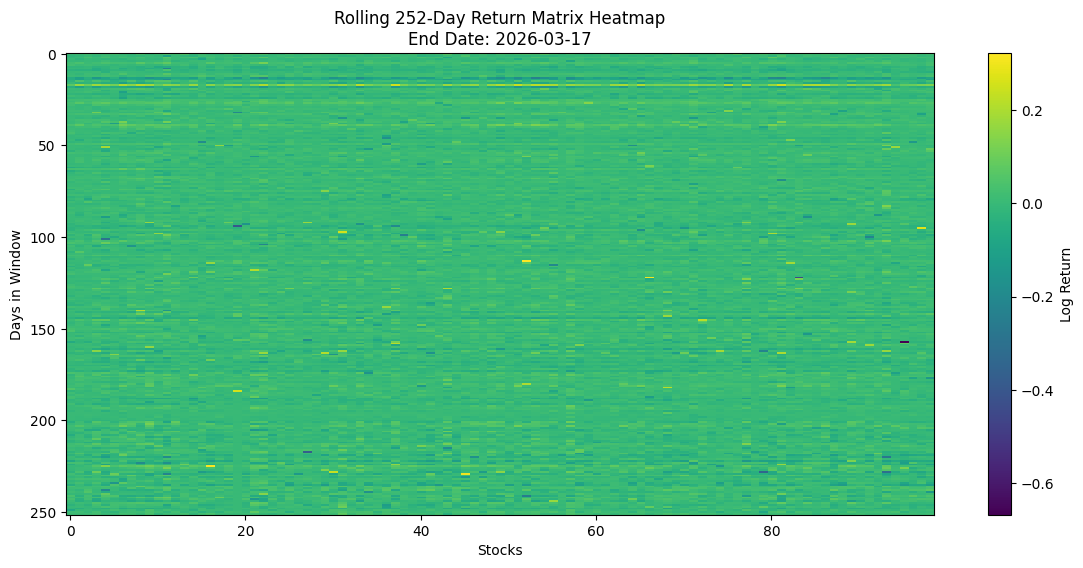

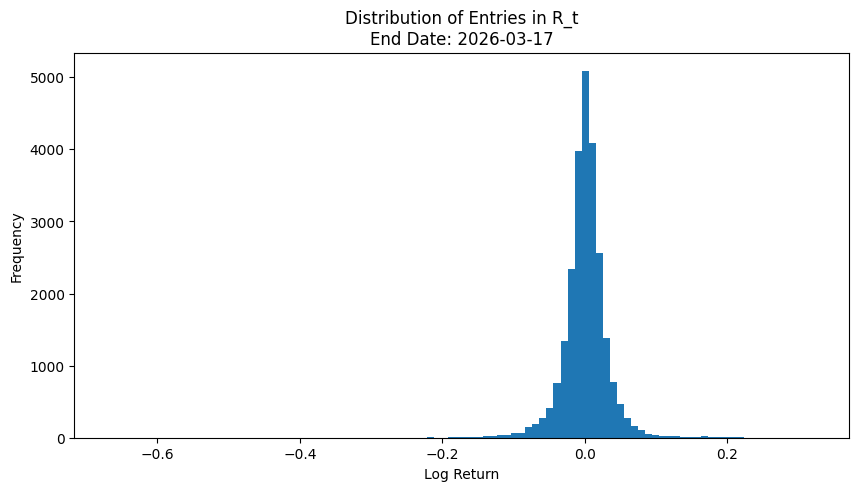

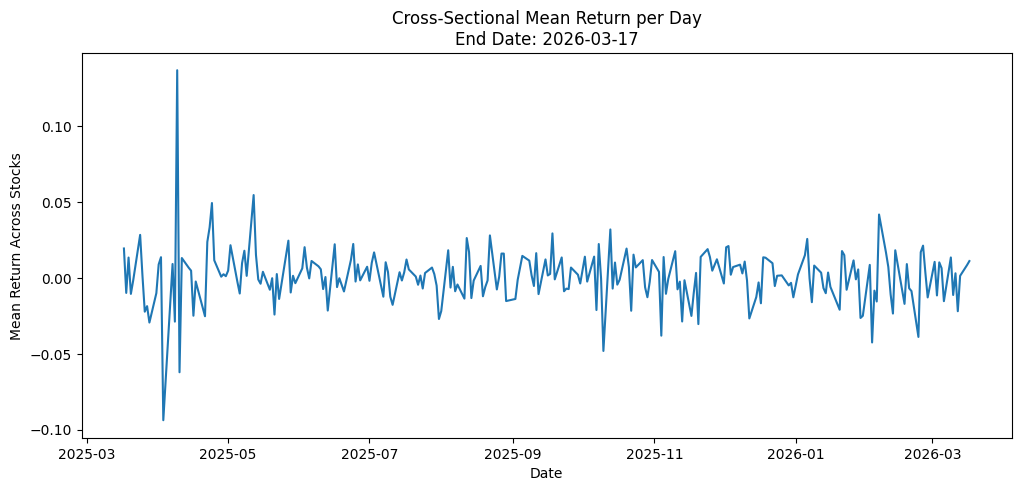

In [11]:
# --------------------------
# Step 2: build rolling 252-day return matrices
# --------------------------

window = 252

# 1) Keep only dates where every stock has a valid return
returns_clean = returns.dropna(axis=0, how="any").copy()

# 2) Optional: make sure every column still has enough data
valid_cols = returns_clean.columns[returns_clean.var() > 0]
returns_clean = returns_clean[valid_cols].copy()

# 3) Quick sanity check
print("returns_clean shape:", returns_clean.shape)
print("Any NaNs left?:", returns_clean.isna().any().any())

# 4) Build list of valid end-dates for rolling windows
window_end_dates = returns_clean.index[window - 1:]

# 5) Example: get one rolling matrix R_t for a chosen end-date
sample_end_date = window_end_dates[-1]   # last available date
sample_loc = returns_clean.index.get_loc(sample_end_date)

R_t = returns_clean.iloc[sample_loc - window + 1 : sample_loc + 1].copy()

print("Sample end date:", sample_end_date)
print("R_t shape:", R_t.shape)
print("Any NaNs in R_t?:", R_t.isna().any().any())

# 6) Extra sanity checks for this window
assert R_t.shape[0] == window, f"Expected {window} rows, got {R_t.shape[0]}"
assert R_t.isna().sum().sum() == 0, "R_t contains NaNs"
assert (R_t.var(axis=0) > 0).all(), "At least one stock has zero variance in this window"

# 7) Function to get rolling matrix for any end-date
def get_rolling_return_matrix(returns_df, end_date, window=252):
    end_loc = returns_df.index.get_loc(end_date)
    R_t = returns_df.iloc[end_loc - window + 1 : end_loc + 1].copy()
    
    assert R_t.shape[0] == window, f"Expected {window} rows, got {R_t.shape[0]}"
    assert R_t.isna().sum().sum() == 0, "R_t contains NaNs"
    assert (R_t.var(axis=0) > 0).all(), "At least one stock has zero variance in this window"
    
    return R_t

# 8) Visualizations for the sample window
# Plot 1: heatmap of R_t
plt.figure(figsize=(14, 6))
plt.imshow(R_t.values, aspect="auto", interpolation="none")
plt.colorbar(label="Log Return")
plt.title(f"Rolling 252-Day Return Matrix Heatmap\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Stocks")
plt.ylabel("Days in Window")
plt.show()

# Plot 2: histogram of all entries in R_t
plt.figure(figsize=(10, 5))
plt.hist(R_t.values.ravel(), bins=100)
plt.title(f"Distribution of Entries in R_t\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

# Plot 3: cross-sectional mean per day
cross_sectional_mean = R_t.mean(axis=1)

plt.figure(figsize=(12, 5))
plt.plot(cross_sectional_mean.index, cross_sectional_mean.values)
plt.title(f"Cross-Sectional Mean Return per Day\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Date")
plt.ylabel("Mean Return Across Stocks")
plt.show()


Y_t shape: (252, 99)
Any NaNs in Y_t?: False
Any infs in Y_t?: False
Max abs column mean: 3.52451753849256e-17
Min column variance: 0.9999999999999996
Max column variance: 1.0000000000000004


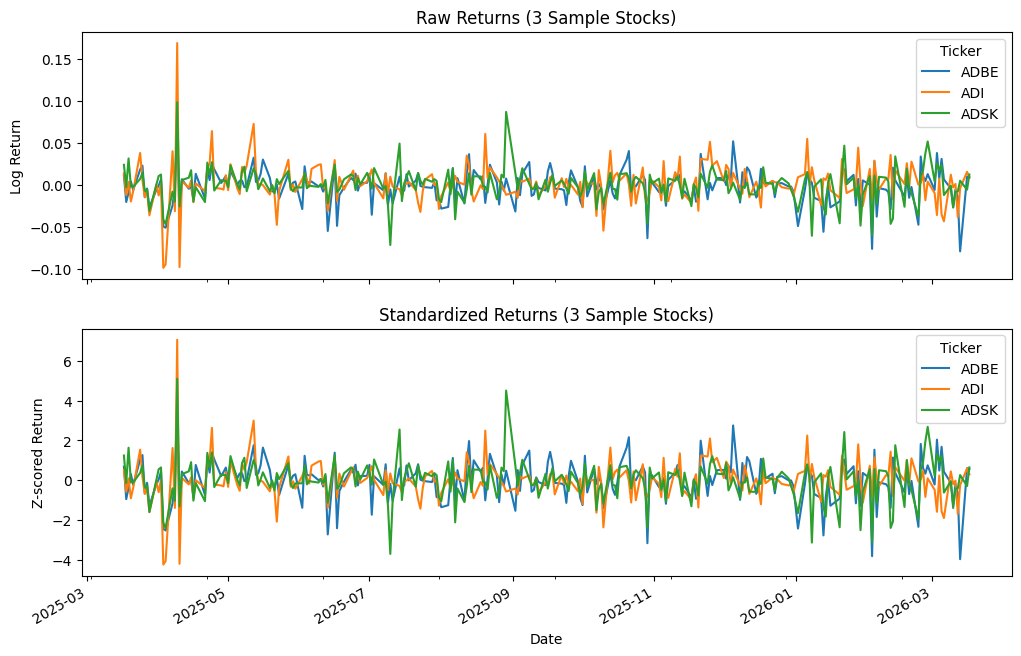

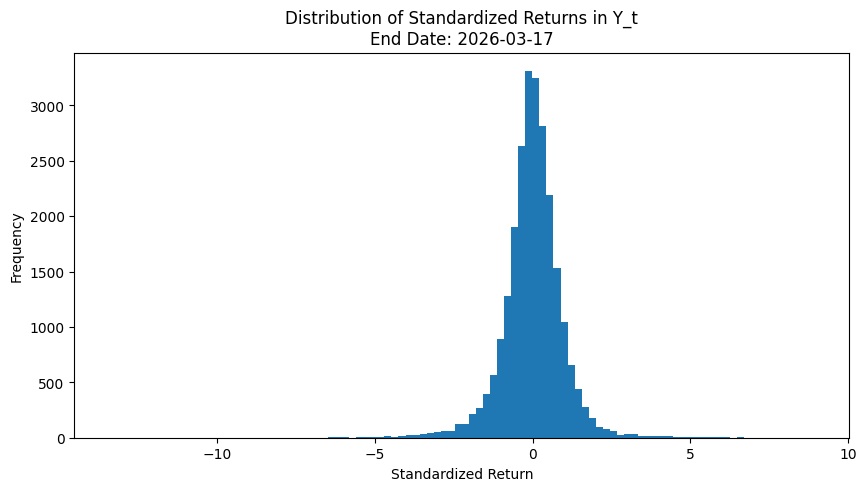

ValueError: Too many bins for data range. Cannot create 40 finite-sized bins.

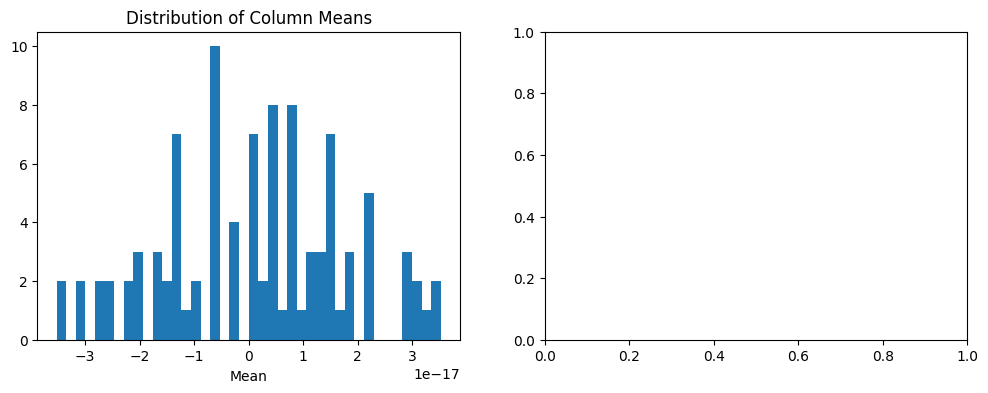

In [12]:

# --------------------------
# Step 3: standardize returns inside the PCA window
# --------------------------

# 1) Compute column-wise mean and std inside this window
mu_t = R_t.mean(axis=0)
sigma_t = R_t.std(axis=0, ddof=1)

# 2) Safety check: no zero std allowed
valid_cols_window = sigma_t[sigma_t > 0].index

R_t = R_t[valid_cols_window].copy()
mu_t = mu_t[valid_cols_window].copy()
sigma_t = sigma_t[valid_cols_window].copy()

# 3) Standardize column-wise
Y_t = (R_t - mu_t) / sigma_t

# 4) Sanity checks
print("Y_t shape:", Y_t.shape)
print("Any NaNs in Y_t?:", Y_t.isna().any().any())
print("Any infs in Y_t?:", np.isinf(Y_t.values).any())

col_means = Y_t.mean(axis=0)
col_vars = Y_t.var(axis=0, ddof=1)

print("Max abs column mean:", np.abs(col_means).max())
print("Min column variance:", col_vars.min())
print("Max column variance:", col_vars.max())

assert Y_t.shape == R_t.shape, "Y_t and R_t shapes do not match"
assert Y_t.isna().sum().sum() == 0, "Y_t contains NaNs"
assert not np.isinf(Y_t.values).any(), "Y_t contains inf values"

# 5) Plot 1: before vs after standardization for 3 sample stocks
sample_stocks = Y_t.columns[:3]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

R_t[sample_stocks].plot(ax=axes[0])
axes[0].set_title("Raw Returns (3 Sample Stocks)")
axes[0].set_ylabel("Log Return")

Y_t[sample_stocks].plot(ax=axes[1])
axes[1].set_title("Standardized Returns (3 Sample Stocks)")
axes[1].set_ylabel("Z-scored Return")
plt.show()

# 6) Plot 2: histogram of standardized entries (all columns together)
plt.figure(figsize=(10, 5))
plt.hist(Y_t.values.ravel(), bins=100)
plt.title(f"Distribution of Standardized Returns in Y_t\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Standardized Return")
plt.ylabel("Frequency")
plt.show()

# 7) Plot 3: distribution of column means and variances
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(col_means.values, bins=40)
axes[0].set_title("Distribution of Column Means")
axes[0].set_xlabel("Mean")

axes[1].hist(col_vars.values, bins=40)
axes[1].set_title("Distribution of Column Variances")
axes[1].set_xlabel("Variance")

plt.show()

Sigma_t shape: (99, 99)
Min diagonal: 0.999999999999999
Max diagonal: 1.0000000000000009
Max symmetry error: 0.0
Min eigenvalue: 0.03102736497825441


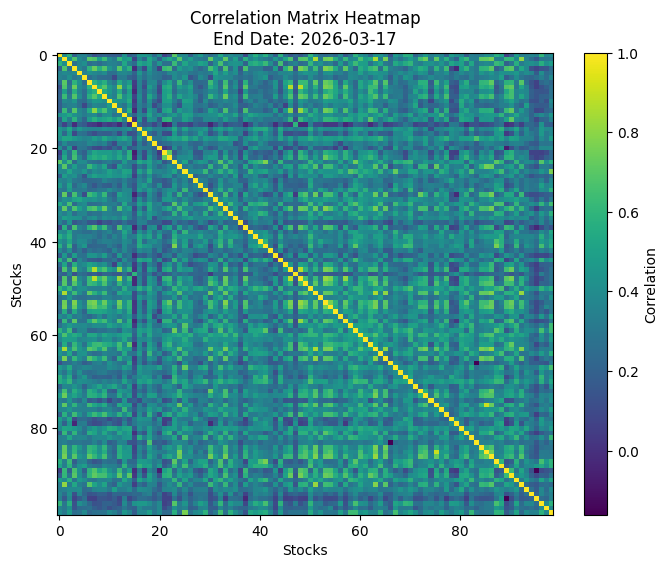

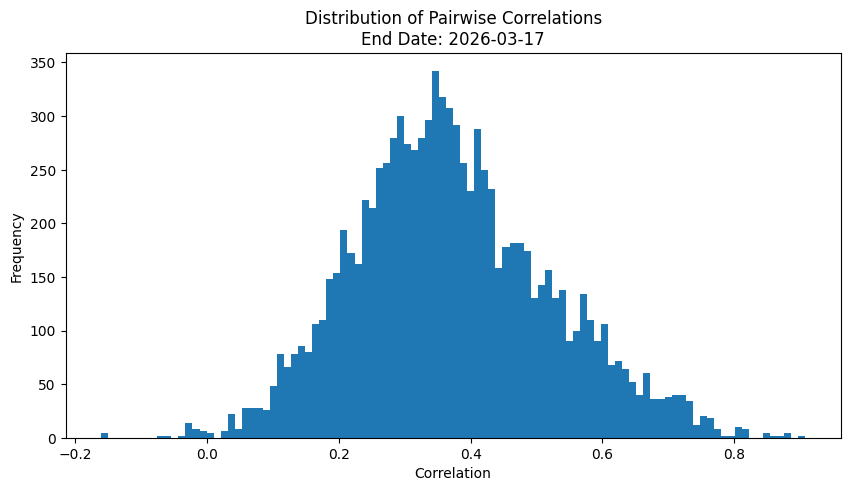

Average correlation: 0.37136728280848974


In [ ]:
# --------------------------
# Step 4: compute correlation matrix Σ_t
# --------------------------

M = Y_t.shape[0]  # should be 252

# 1) Compute correlation matrix
Sigma_t = (Y_t.T @ Y_t) / (M - 1)

# 2) Convert to DataFrame for readability
Sigma_t = pd.DataFrame(
    Sigma_t,
    index=Y_t.columns,
    columns=Y_t.columns
)

# --------------------------
# 3) Sanity checks
# --------------------------

# Shape
print("Sigma_t shape:", Sigma_t.shape)

# Diagonal ≈ 1
diag_vals = np.diag(Sigma_t)
print("Min diagonal:", diag_vals.min())
print("Max diagonal:", diag_vals.max())

# Symmetry check
symmetry_error = np.abs(Sigma_t.values - Sigma_t.values.T).max()
print("Max symmetry error:", symmetry_error)

# Eigenvalues (should be >= 0)
eigvals = np.linalg.eigvalsh(Sigma_t.values)
print("Min eigenvalue:", eigvals.min())

# Assertions
assert Sigma_t.shape[0] == Sigma_t.shape[1], "Matrix not square"
assert np.allclose(diag_vals, 1, atol=1e-6), "Diagonal not ~1"
assert symmetry_error < 1e-10, "Matrix not symmetric"
assert eigvals.min() > -1e-8, "Matrix not PSD (numerical issue)"

# --------------------------
# 4) Plot 1: heatmap
# --------------------------
plt.figure(figsize=(8, 6))
plt.imshow(Sigma_t.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.title(f"Correlation Matrix Heatmap\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Stocks")
plt.ylabel("Stocks")
plt.show()

# --------------------------
# 5) Plot 2: distribution of correlations (off-diagonal)
# --------------------------
corr_vals = Sigma_t.values
off_diag = corr_vals[~np.eye(corr_vals.shape[0], dtype=bool)]

plt.figure(figsize=(10, 5))
plt.hist(off_diag, bins=100)
plt.title(f"Distribution of Pairwise Correlations\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.show()

# --------------------------
# 6) Compute average correlation
# --------------------------
N = Sigma_t.shape[0]
avg_corr = off_diag.mean()

print("Average correlation:", avg_corr)


Top 10 eigenvalues:
[38.54479308 10.43647935  4.07247972  2.14299001  1.94892389  1.76957139
  1.54871107  1.47294985  1.41125616  1.29923978]

Total variance (sum of eigenvalues): 99.00000000000003
Explained variance by top 10: 0.6530039828266031
Minimum eigenvalue: 0.031027364978254188
Max orthogonality error: 2.1094237467877974e-15


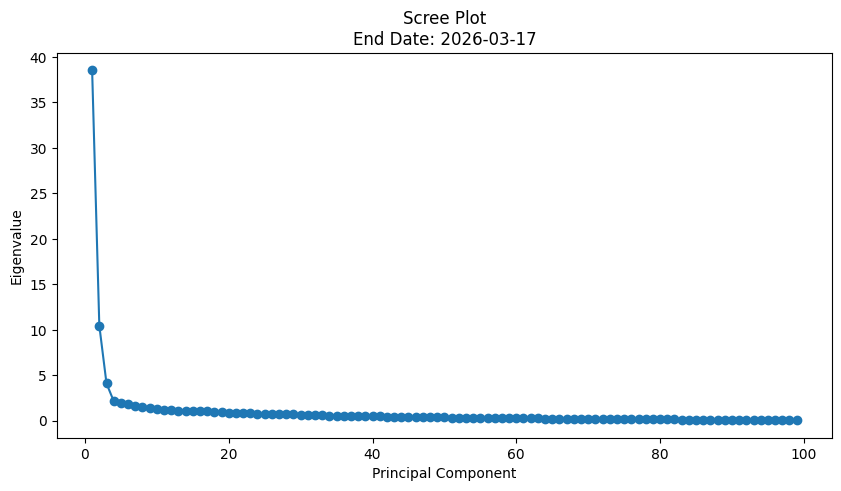

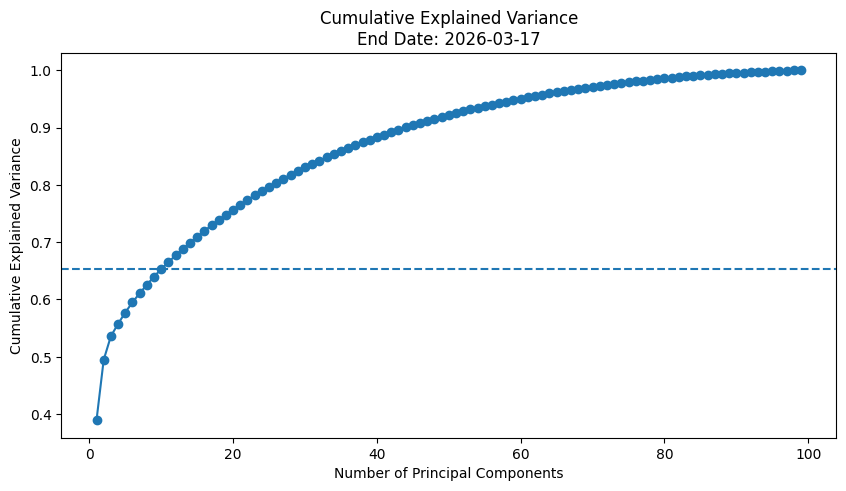

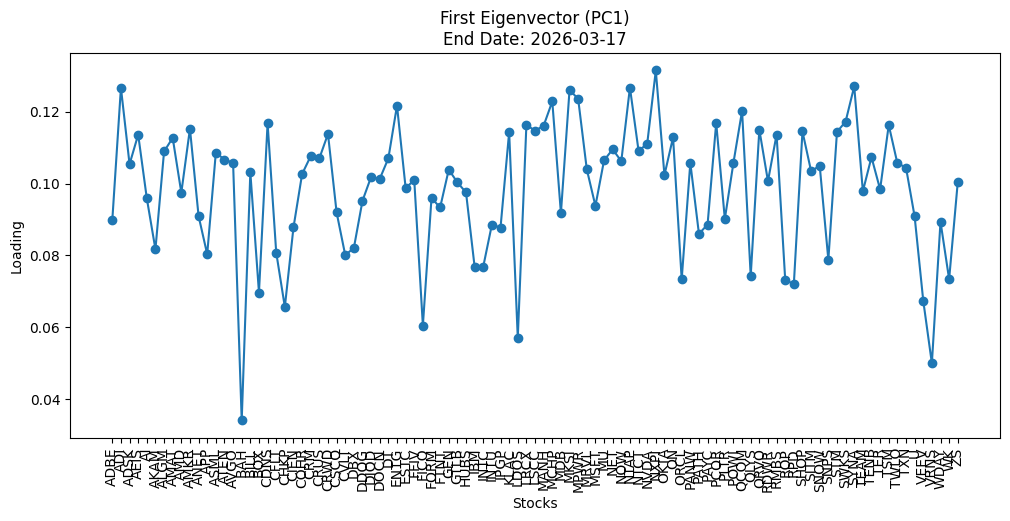

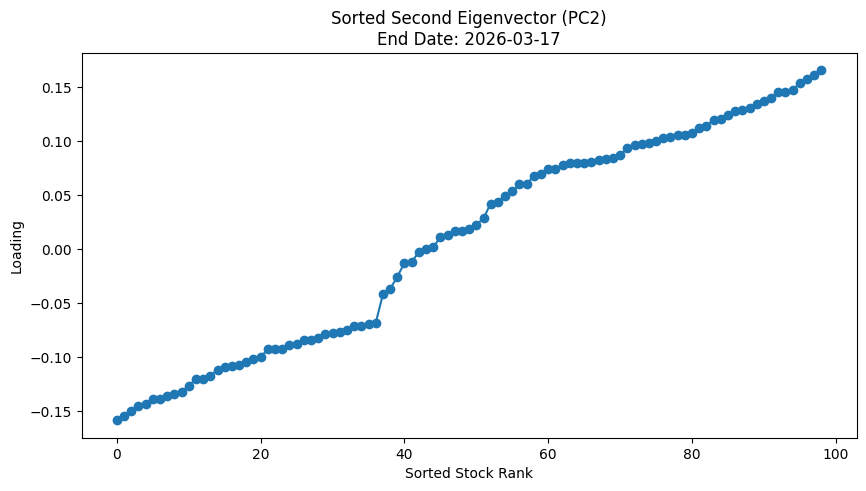

In [14]:
# --------------------------
# Step 5: PCA via eigen-decomposition of Sigma_t
# --------------------------

# 1) Eigen-decomposition of symmetric correlation matrix
eigvals, eigvecs = np.linalg.eigh(Sigma_t.values)

# 2) Sort in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# 3) Keep top K factors
eigvals_k = eigvals[:K]
eigvecs_k = eigvecs[:, :K]

# 4) Put eigenvectors into DataFrame for readability
V_k = pd.DataFrame(
    eigvecs_k,
    index=Sigma_t.index,
    columns=[f"PC{j+1}" for j in range(K)]
)

# 5) Explained variance
total_variance = eigvals.sum()
explained_ratio = eigvals / total_variance
cum_explained_ratio = np.cumsum(explained_ratio)

print("Top 10 eigenvalues:")
print(eigvals_k)

print("\nTotal variance (sum of eigenvalues):", total_variance)
print("Explained variance by top 10:", explained_ratio[:K].sum())

# --------------------------
# 6) Sanity checks
# --------------------------

# all eigenvalues should be nonnegative up to numerical error
print("Minimum eigenvalue:", eigvals.min())

# eigenvectors should be orthonormal
orthogonality_check = eigvecs.T @ eigvecs
max_orth_error = np.abs(orthogonality_check - np.eye(len(eigvals))).max()
print("Max orthogonality error:", max_orth_error)

assert eigvals.min() > -1e-8, "Negative eigenvalue beyond numerical tolerance"
assert np.isclose(total_variance, Sigma_t.shape[0], atol=1e-6), "Sum of eigenvalues not equal to N"
assert max_orth_error < 1e-10, "Eigenvectors are not orthonormal"

# --------------------------
# 7) Plot 1: scree plot
# --------------------------
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(eigvals) + 1), eigvals, marker="o")
plt.title(f"Scree Plot\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.show()

# --------------------------
# 8) Plot 2: cumulative explained variance
# --------------------------
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_explained_ratio) + 1), cum_explained_ratio, marker="o")
plt.axhline(y=explained_ratio[:K].sum(), linestyle="--")
plt.title(f"Cumulative Explained Variance\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

# --------------------------
# 9) Plot 3: first eigenvector (market factor candidate)
# --------------------------
plt.figure(figsize=(12, 5))
plt.plot(V_k.index, V_k["PC1"].values, marker="o")
plt.xticks(rotation=90)
plt.title(f"First Eigenvector (PC1)\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Stocks")
plt.ylabel("Loading")
plt.show()

# --------------------------
# 10) Plot 4: sorted second eigenvector
# --------------------------
pc2_sorted = np.sort(V_k["PC2"].values)

plt.figure(figsize=(10, 5))
plt.plot(pc2_sorted, marker="o")
plt.title(f"Sorted Second Eigenvector (PC2)\nEnd Date: {sample_end_date.date()}")
plt.xlabel("Sorted Stock Rank")
plt.ylabel("Loading")
plt.show()

Target stock: ADBE
Observed standardized return: 0.563845804650229
Systematic component: 0.2868581159478706
Reconstruction error (partial PCA): 4.328009065481104


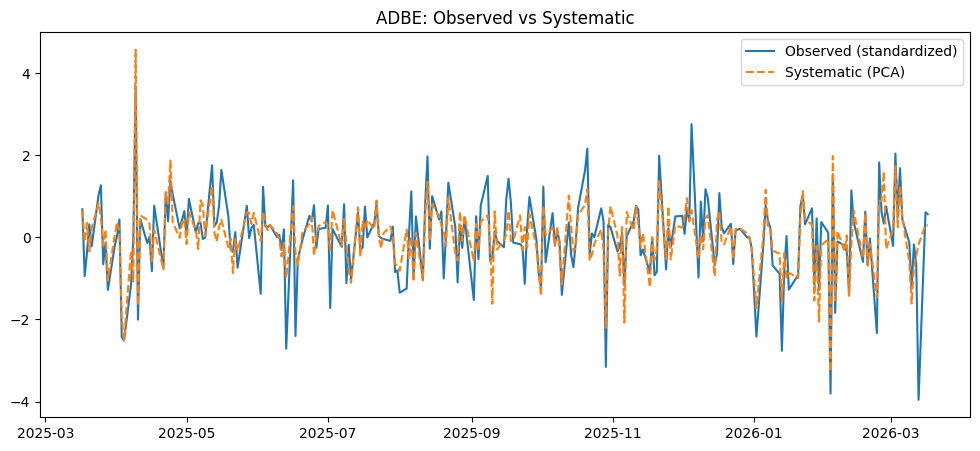

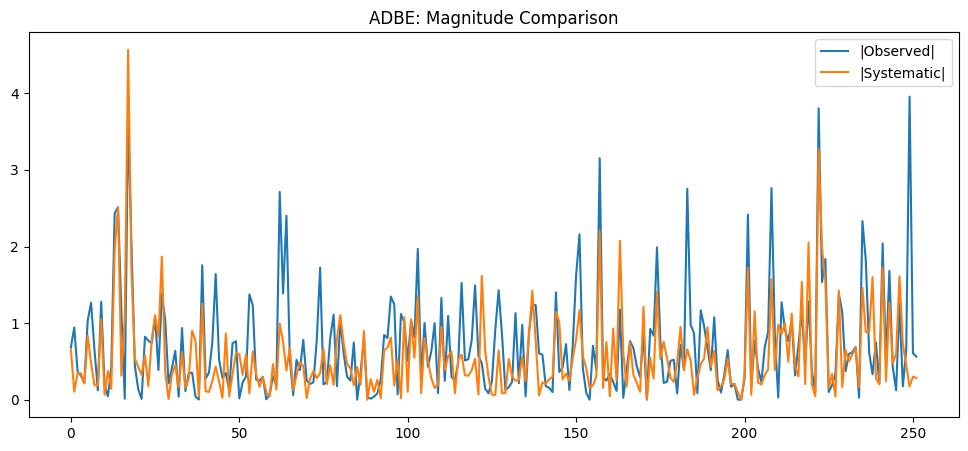

Correlation (observed vs systematic): 0.7982852717207635


In [15]:
# --------------------------
# Step 6: PCA projection → systematic component
# --------------------------

# choose a stock (change this)
target_stock = Y_t.columns[0]

# 1) current standardized return vector y_t (last row of window)
y_t_vec = Y_t.iloc[-1].values   # shape (N,)

# 2) top-K eigenvectors matrix (N x K)
V = eigvecs_k   # from Step 5

# 3) compute factor scores (projection)
# z_t = V^T y_t
z_t = V.T @ y_t_vec   # shape (K,)

# 4) reconstruct systematic component
# y_sys = V z_t
y_sys = V @ z_t       # shape (N,)

# 5) convert to Series for readability
y_sys = pd.Series(y_sys, index=Y_t.columns)

# 6) extract chosen stock
Y_i_t = Y_t[target_stock].iloc[-1]
Y_i_sys = y_sys[target_stock]

print("Target stock:", target_stock)
print("Observed standardized return:", Y_i_t)
print("Systematic component:", Y_i_sys)

# --------------------------
# 7) sanity checks
# --------------------------

# if K = N, reconstruction should be exact
# (not here since K=10, but useful check)
reconstruction_error = np.linalg.norm(y_t_vec - y_sys.values)
print("Reconstruction error (partial PCA):", reconstruction_error)

# --------------------------
# 8) simple visualization across window
# --------------------------

# project entire window (not just last point)
Y_matrix = Y_t.values              # (252 x N)
Z_matrix = Y_matrix @ V            # (252 x K)
Y_sys_matrix = Z_matrix @ V.T      # (252 x N)

Y_sys_df = pd.DataFrame(
    Y_sys_matrix,
    index=Y_t.index,
    columns=Y_t.columns
)

# extract time series for chosen stock
obs_series = Y_t[target_stock]
sys_series = Y_sys_df[target_stock]

# Plot 1: observed vs systematic
plt.figure(figsize=(12,5))
plt.plot(obs_series.index, obs_series.values, label="Observed (standardized)")
plt.plot(sys_series.index, sys_series.values, label="Systematic (PCA)", linestyle="--")
plt.title(f"{target_stock}: Observed vs Systematic")
plt.legend()
plt.show()

# Plot 2: magnitude comparison
plt.figure(figsize=(12,5))
plt.plot(np.abs(obs_series.values), label="|Observed|")
plt.plot(np.abs(sys_series.values), label="|Systematic|")
plt.title(f"{target_stock}: Magnitude Comparison")
plt.legend()
plt.show()

# Plot 3: correlation
corr_val = np.corrcoef(obs_series.values, sys_series.values)[0,1]
print("Correlation (observed vs systematic):", corr_val)

Target stock: ADBE
Current standardized residual: 0.27698768870235857
Current raw residual return: 0.005400977824185516
Max decomposition error: 1.1102230246251565e-16
Rolling PCA R^2 for target stock: 0.6372593750462923


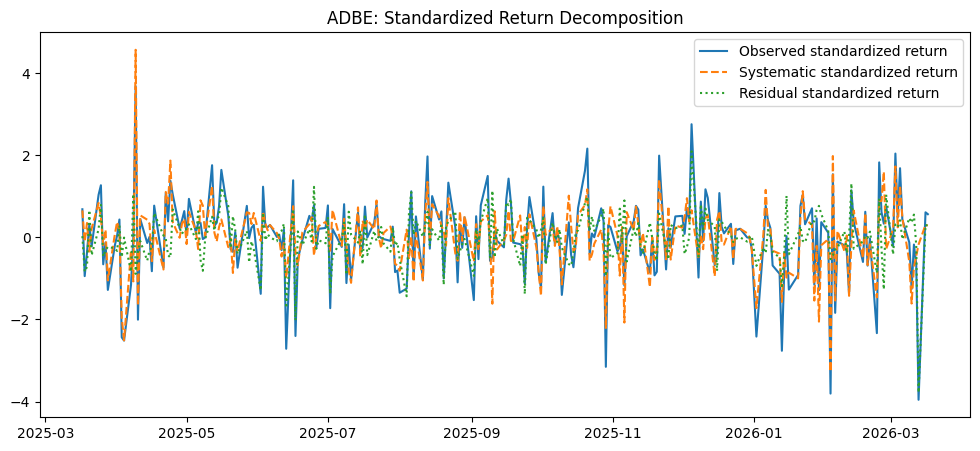

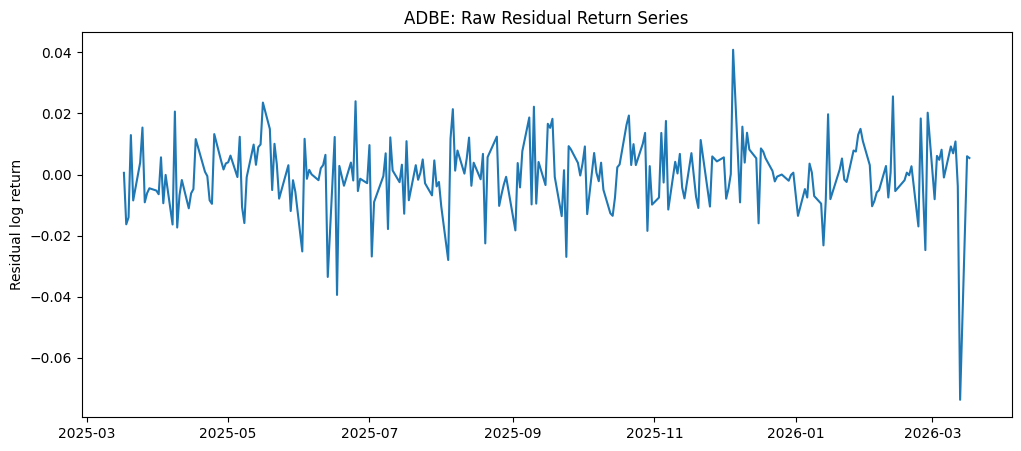

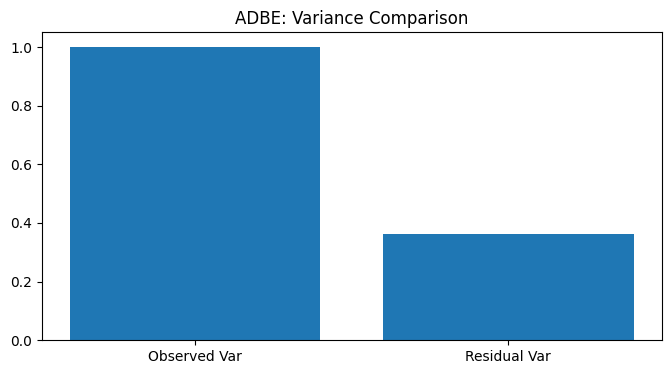

In [16]:
# --------------------------
# Step 7: compute residual return for chosen stock
# --------------------------

# target_stock already chosen in Step 6

# 1) standardized residual return
resid_std_series = obs_series - sys_series

# 2) get this stock's rolling-window std from Step 3
sigma_i_t = sigma_t[target_stock]

# 3) convert standardized residual at current t to raw residual return
resid_raw_t = sigma_i_t * resid_std_series.iloc[-1]

print("Target stock:", target_stock)
print("Current standardized residual:", resid_std_series.iloc[-1])
print("Current raw residual return:", resid_raw_t)

# 4) convert full window standardized residual series to raw residual return series
resid_raw_series = sigma_i_t * resid_std_series

# --------------------------
# 5) sanity check
# --------------------------
rebuild_check = sys_series + resid_std_series
max_rebuild_error = np.max(np.abs(obs_series - rebuild_check))

print("Max decomposition error:", max_rebuild_error)

assert max_rebuild_error < 1e-10, "Observed != systematic + residual"

# --------------------------
# 6) rolling R^2 inside this window
# --------------------------
var_obs = np.var(obs_series.values, ddof=1)
var_resid = np.var(resid_std_series.values, ddof=1)
R2_i_t = 1 - (var_resid / var_obs)

print("Rolling PCA R^2 for target stock:", R2_i_t)

# --------------------------
# 7) Plot 1: decomposition in standardized units
# --------------------------
plt.figure(figsize=(12, 5))
plt.plot(obs_series.index, obs_series.values, label="Observed standardized return")
plt.plot(sys_series.index, sys_series.values, label="Systematic standardized return", linestyle="--")
plt.plot(resid_std_series.index, resid_std_series.values, label="Residual standardized return", linestyle=":")
plt.title(f"{target_stock}: Standardized Return Decomposition")
plt.legend()
plt.show()

# --------------------------
# 8) Plot 2: raw residual return series
# --------------------------
plt.figure(figsize=(12, 5))
plt.plot(resid_raw_series.index, resid_raw_series.values)
plt.title(f"{target_stock}: Raw Residual Return Series")
plt.ylabel("Residual log return")
plt.show()

# --------------------------
# 9) Plot 3: bar plot of variance split
# --------------------------
plt.figure(figsize=(8, 4))
plt.bar(["Observed Var", "Residual Var"], [var_obs, var_resid])
plt.title(f"{target_stock}: Variance Comparison")
plt.show()

Target stock: ADBE
Max first-difference error: 6.938893903907228e-18


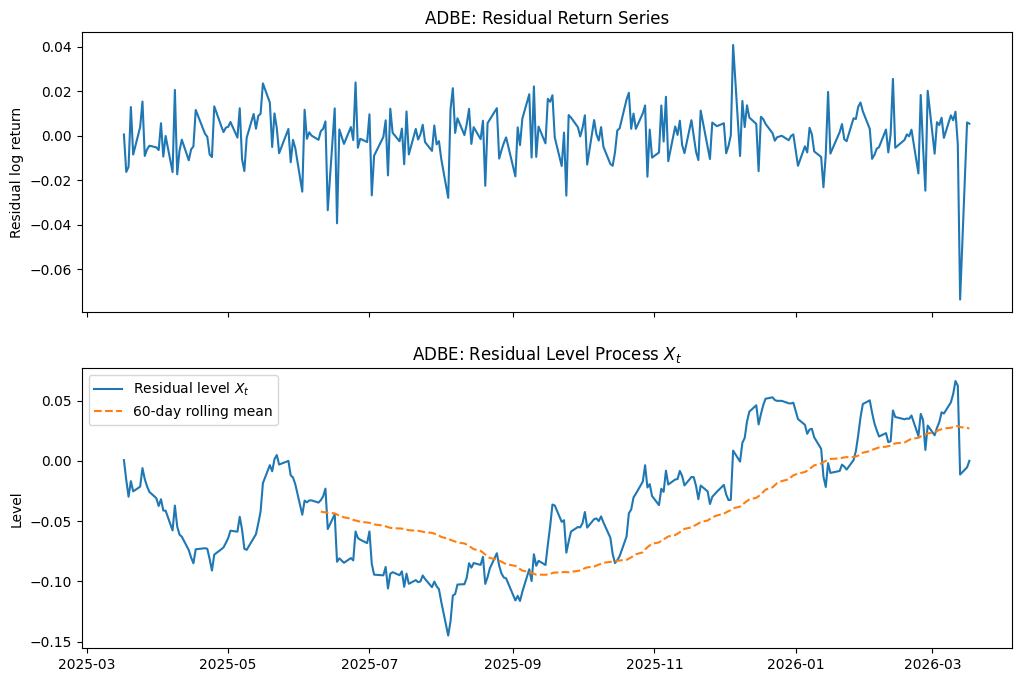

X_t mean: -0.03521779509151423
X_t std: 0.04852004622564758
Residual return mean: 0.0
Residual return std: 0.01174383730910105


In [17]:
# --------------------------
# Step 8: build residual level process X_t
# --------------------------

# 1) cumulative residual level
X_t = resid_raw_series.cumsum()

# optional: force explicit zero-start interpretation
# X_t = resid_raw_series.cumsum()
# X_t.iloc[0] = resid_raw_series.iloc[0]

# 2) sanity check: first differences recover residual returns
diff_check = X_t.diff()
max_diff_error = np.max(np.abs(diff_check.iloc[1:] - resid_raw_series.iloc[1:]))

print("Target stock:", target_stock)
print("Max first-difference error:", max_diff_error)

assert max_diff_error < 1e-10, "X_t.diff() does not recover residual return series"

# 3) 60-day rolling mean of level
rolling_mean_60 = X_t.rolling(60).mean()

# --------------------------
# 4) Plot 1 + 2: residual return and residual level
# --------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(resid_raw_series.index, resid_raw_series.values)
axes[0].set_title(f"{target_stock}: Residual Return Series")
axes[0].set_ylabel("Residual log return")

axes[1].plot(X_t.index, X_t.values, label="Residual level $X_t$")
axes[1].plot(rolling_mean_60.index, rolling_mean_60.values, linestyle="--", label="60-day rolling mean")
axes[1].set_title(f"{target_stock}: Residual Level Process $X_t$")
axes[1].set_ylabel("Level")
axes[1].legend()

plt.show()

# --------------------------
# 5) Extra quick summary stats
# --------------------------
print("X_t mean:", X_t.mean())
print("X_t std:", X_t.std(ddof=1))
print("Residual return mean:", resid_raw_series.mean())
print("Residual return std:", resid_raw_series.std(ddof=1))

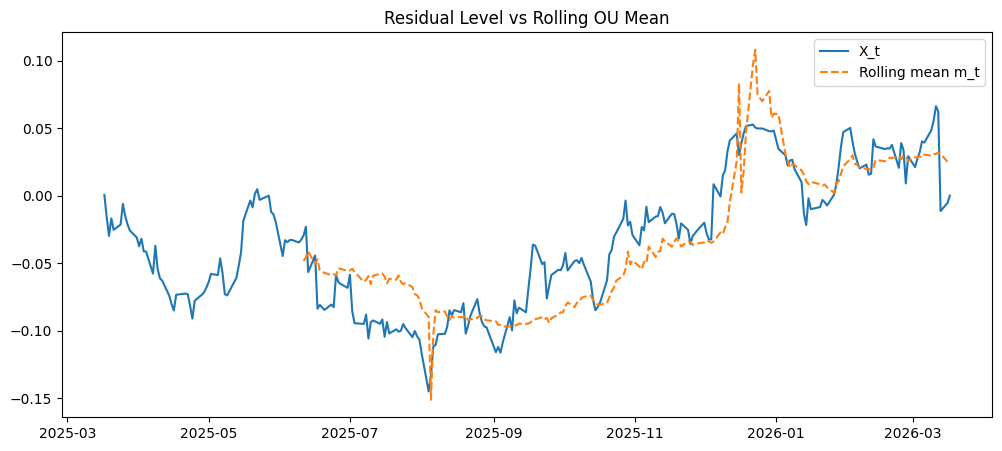

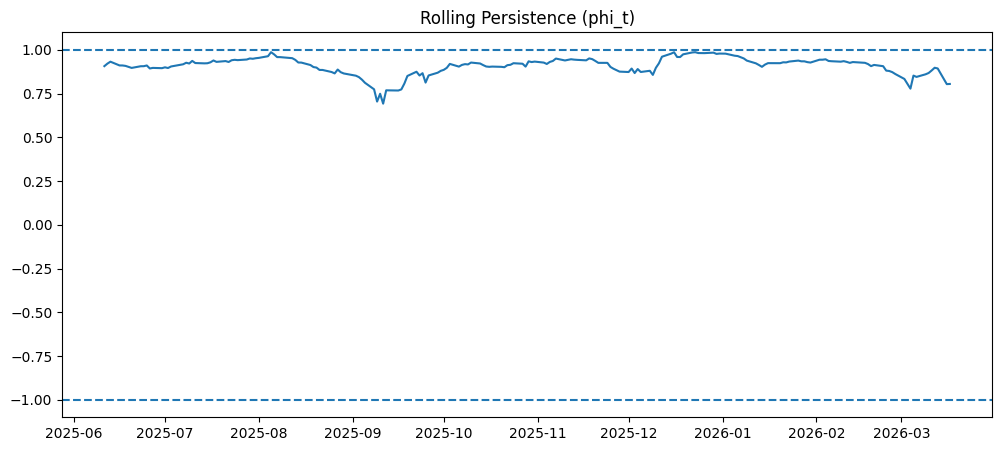

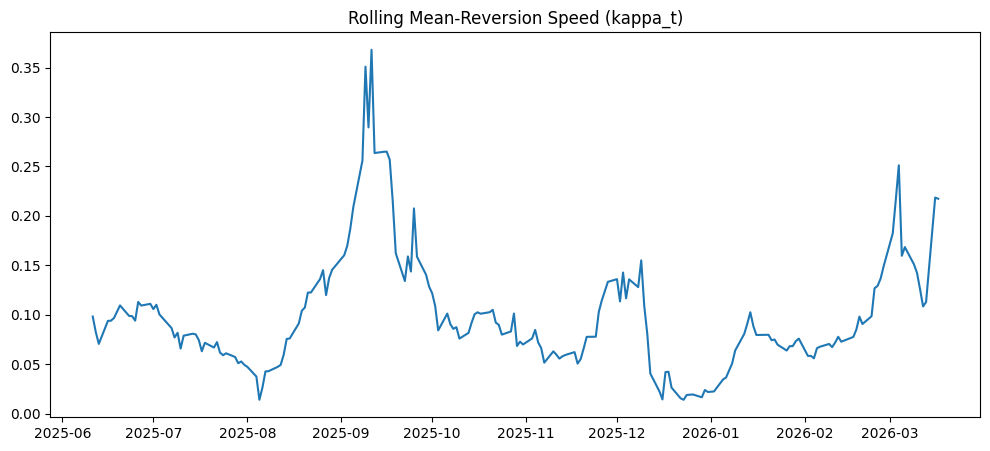

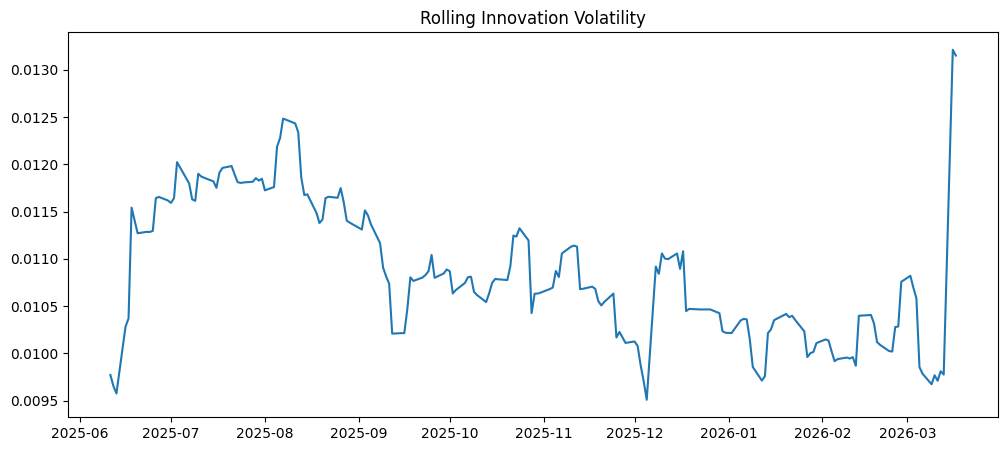

In [18]:
# --------------------------
# Step 9: rolling AR(1) / OU fit
# --------------------------

L = 60  # window

# storage
c_list = []
phi_list = []
kappa_list = []
m_list = []
sigma_eps_list = []
dates = []

X_vals = X_t.values

for t in range(L, len(X_t)):

    # window slice
    X_window = X_vals[t-L:t]

    # build regression data
    X_lag = X_window[:-1]   # X_{t-1}
    X_curr = X_window[1:]   # X_t

    # add constant
    X_reg = sm.add_constant(X_lag)

    # OLS
    model = sm.OLS(X_curr, X_reg).fit()

    c_hat = model.params[0]
    phi_hat = model.params[1]

    # residuals
    eps = model.resid
    sigma_eps = np.sqrt(np.sum(eps**2) / (len(eps) - 2))

    # OU parameters
    if phi_hat > 0 and phi_hat < 1:
        kappa_hat = -np.log(phi_hat)
        m_hat = c_hat / (1 - phi_hat)
    else:
        kappa_hat = np.nan
        m_hat = np.nan

    # store
    c_list.append(c_hat)
    phi_list.append(phi_hat)
    kappa_list.append(kappa_hat)
    m_list.append(m_hat)
    sigma_eps_list.append(sigma_eps)
    dates.append(X_t.index[t])

# convert to series
c_series = pd.Series(c_list, index=dates)
phi_series = pd.Series(phi_list, index=dates)
kappa_series = pd.Series(kappa_list, index=dates)
m_series = pd.Series(m_list, index=dates)
sigma_eps_series = pd.Series(sigma_eps_list, index=dates)

# --------------------------
# plots
# --------------------------

# Plot 1: X_t vs equilibrium mean
plt.figure(figsize=(12,5))
plt.plot(X_t.index, X_t.values, label="X_t")
plt.plot(m_series.index, m_series.values, label="Rolling mean m_t", linestyle="--")
plt.title("Residual Level vs Rolling OU Mean")
plt.legend()
plt.show()

# Plot 2: phi_t
plt.figure(figsize=(12,5))
plt.plot(phi_series.index, phi_series.values)
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.title("Rolling Persistence (phi_t)")
plt.show()

# Plot 3: kappa_t
plt.figure(figsize=(12,5))
plt.plot(kappa_series.index, kappa_series.values)
plt.title("Rolling Mean-Reversion Speed (kappa_t)")
plt.show()

# Plot 4: sigma_eps_t
plt.figure(figsize=(12,5))
plt.plot(sigma_eps_series.index, sigma_eps_series.values)
plt.title("Rolling Innovation Volatility")
plt.show()

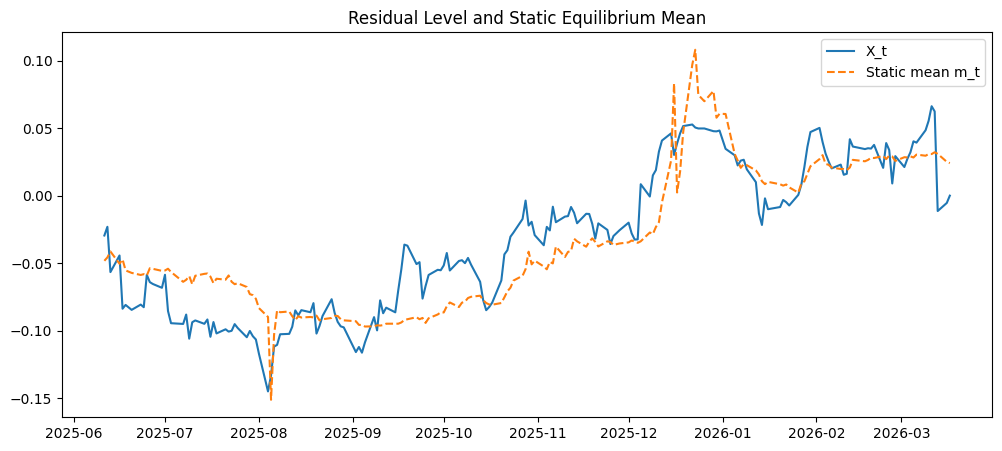

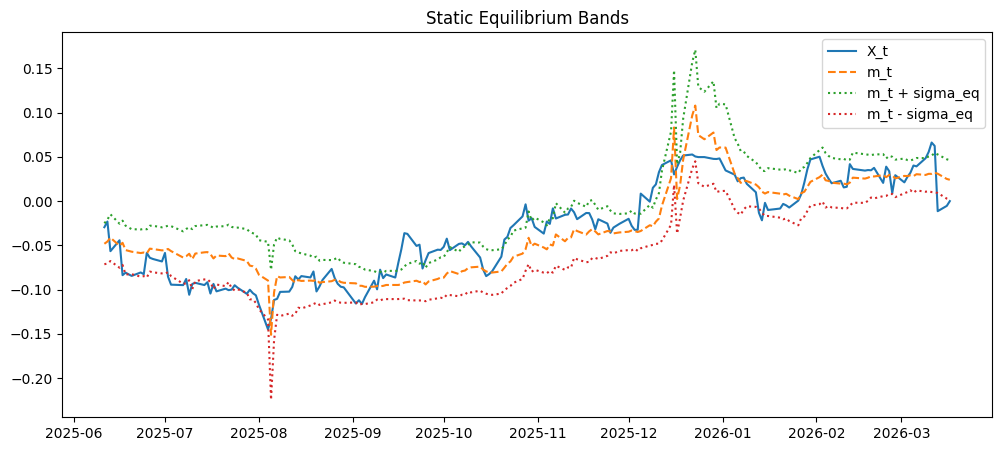

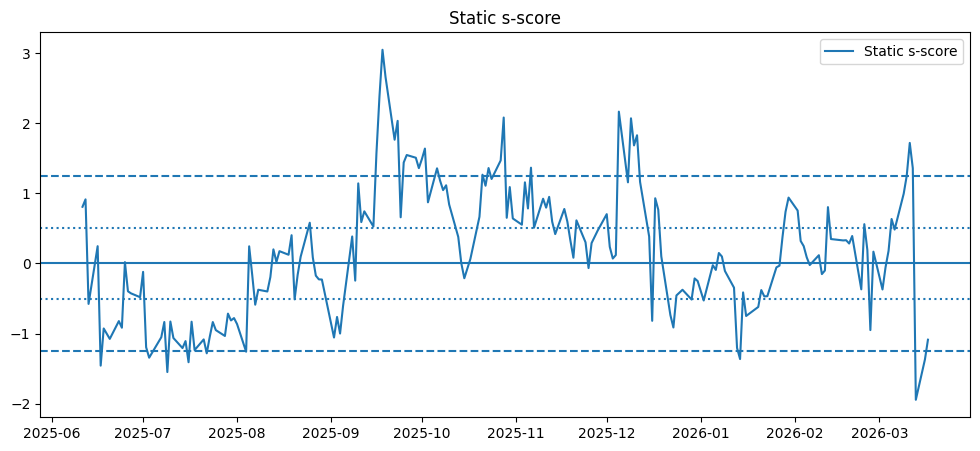

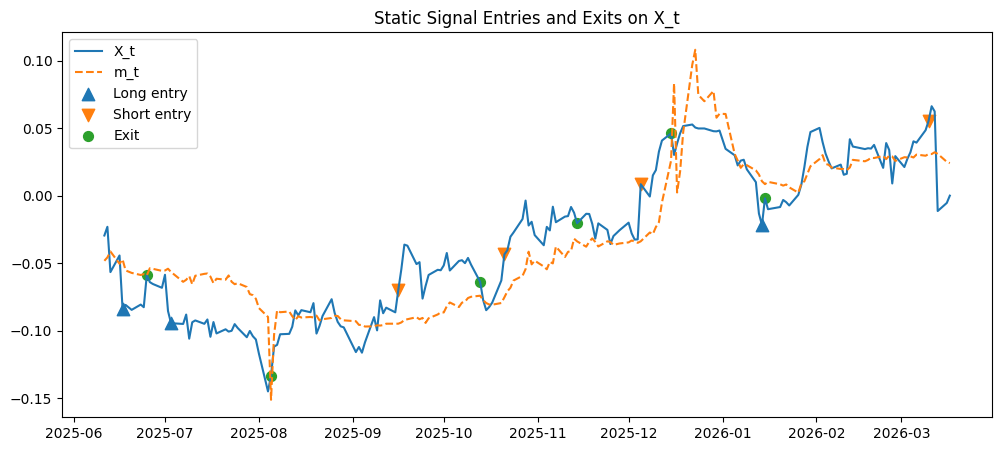

Valid static signal points: 192
First 5 s-scores:
2025-06-11    0.808413
2025-06-12    0.914670
2025-06-13   -0.577017
2025-06-16    0.246434
2025-06-17   -1.457898
dtype: float64
Long entries: 3
Short entries: 4
Exits: 6


In [19]:
# --------------------------
# Step 10: static equilibrium variance and static s-score
# --------------------------

# 1) valid regime mask
valid_static = (
    phi_series.notna() &
    sigma_eps_series.notna() &
    (np.abs(phi_series) < 1) &
    (1 - phi_series**2 > 0)
)

# 2) equilibrium volatility
sigma_eq_series = pd.Series(np.nan, index=phi_series.index)
sigma_eq_series.loc[valid_static] = (
    sigma_eps_series.loc[valid_static] /
    np.sqrt(1 - phi_series.loc[valid_static]**2)
)

# 3) align X_t to rolling-OU dates
X_aligned = X_t.reindex(phi_series.index)

# 4) static s-score
s_static = pd.Series(np.nan, index=phi_series.index)
valid_s = valid_static & sigma_eq_series.notna() & (sigma_eq_series > 0) & m_series.notna()

s_static.loc[valid_s] = (
    (X_aligned.loc[valid_s] - m_series.loc[valid_s]) /
    sigma_eq_series.loc[valid_s]
)

# --------------------------
# 5) benchmark thresholds
# --------------------------
s_entry = 1.25
s_exit = 0.50

# 6) simple state machine for positions
position = []
pos = 0   # 1 = long, -1 = short, 0 = flat

long_entries = []
short_entries = []
exits = []

for dt in s_static.index:
    s = s_static.loc[dt]

    if np.isnan(s):
        position.append(pos)
        continue

    if pos == 0:
        if s < -s_entry:
            pos = 1
            long_entries.append(dt)
        elif s > s_entry:
            pos = -1
            short_entries.append(dt)

    elif pos == 1:
        if abs(s) < s_exit:
            pos = 0
            exits.append(dt)

    elif pos == -1:
        if abs(s) < s_exit:
            pos = 0
            exits.append(dt)

    position.append(pos)

position_series = pd.Series(position, index=s_static.index)

# --------------------------
# 7) plots
# --------------------------

# Plot 1: X_t and m_t
plt.figure(figsize=(12, 5))
plt.plot(X_aligned.index, X_aligned.values, label="X_t")
plt.plot(m_series.index, m_series.values, label="Static mean m_t", linestyle="--")
plt.title("Residual Level and Static Equilibrium Mean")
plt.legend()
plt.show()

# Plot 2: equilibrium bands
upper_band = m_series + sigma_eq_series
lower_band = m_series - sigma_eq_series

plt.figure(figsize=(12, 5))
plt.plot(X_aligned.index, X_aligned.values, label="X_t")
plt.plot(m_series.index, m_series.values, label="m_t", linestyle="--")
plt.plot(upper_band.index, upper_band.values, linestyle=":", label="m_t + sigma_eq")
plt.plot(lower_band.index, lower_band.values, linestyle=":", label="m_t - sigma_eq")
plt.title("Static Equilibrium Bands")
plt.legend()
plt.show()

# Plot 3: static s-score
plt.figure(figsize=(12, 5))
plt.plot(s_static.index, s_static.values, label="Static s-score")
plt.axhline(s_entry, linestyle="--")
plt.axhline(-s_entry, linestyle="--")
plt.axhline(s_exit, linestyle=":")
plt.axhline(-s_exit, linestyle=":")
plt.axhline(0, linestyle="-")
plt.title("Static s-score")
plt.legend()
plt.show()

# Plot 4: entries/exits on X_t
plt.figure(figsize=(12, 5))
plt.plot(X_aligned.index, X_aligned.values, label="X_t")
plt.plot(m_series.index, m_series.values, label="m_t", linestyle="--")

plt.scatter(long_entries, X_aligned.loc[long_entries], marker="^", s=80, label="Long entry")
plt.scatter(short_entries, X_aligned.loc[short_entries], marker="v", s=80, label="Short entry")
plt.scatter(exits, X_aligned.loc[exits], marker="o", s=50, label="Exit")

plt.title("Static Signal Entries and Exits on X_t")
plt.legend()
plt.show()

# --------------------------
# 8) quick diagnostics
# --------------------------
print("Valid static signal points:", valid_s.sum())
print("First 5 s-scores:")
print(s_static.dropna().head())

print("Long entries:", len(long_entries))
print("Short entries:", len(short_entries))
print("Exits:", len(exits))

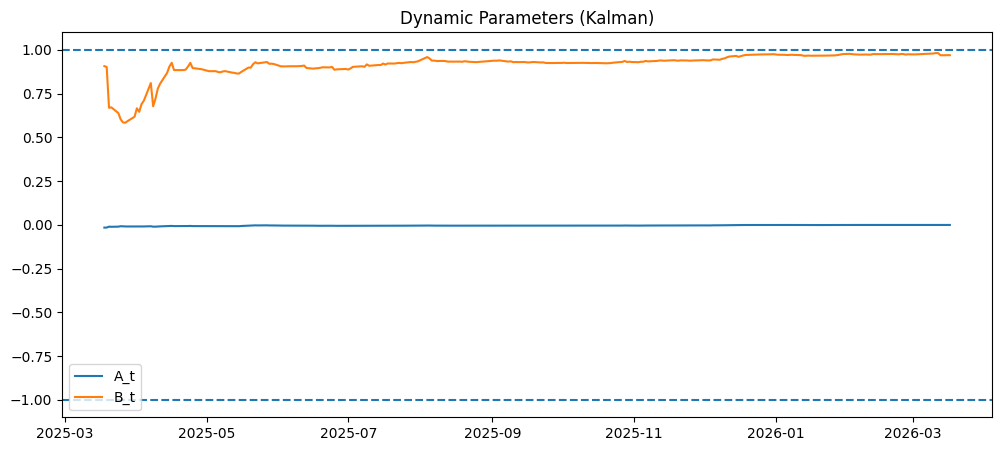

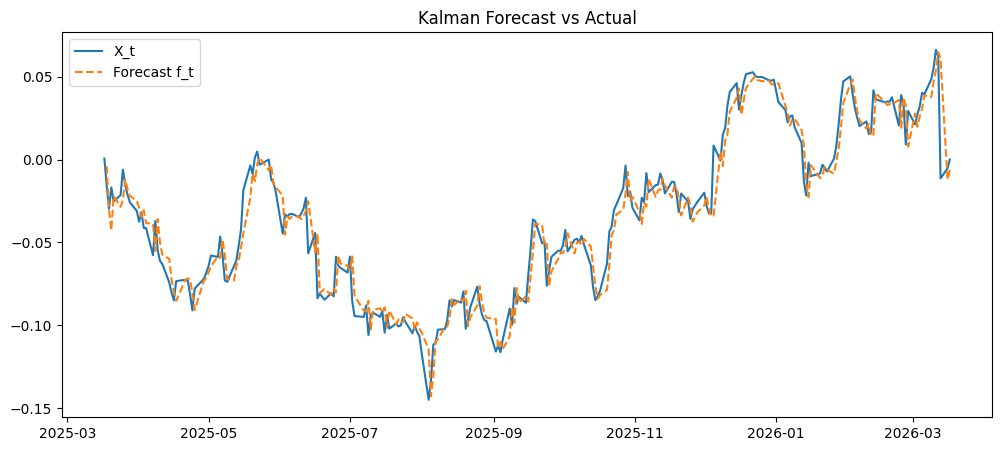

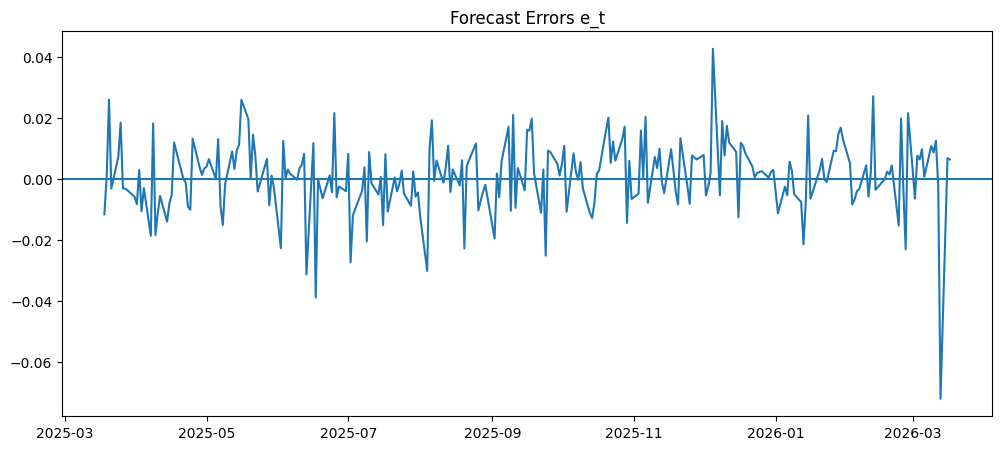

In [20]:
# --------------------------
# Step 11: Kalman TV-AR(1)
# --------------------------

y = X_t.copy().dropna()
y_vals = y.values
dates = y.index

# 1) observation variance (from static model)
sigma2 = np.nanmean(sigma_eps_series.values)**2

# 2) process noise (small)
q_A = 1e-5
q_B = 1e-5
V = np.array([[q_A, 0],
              [0, q_B]])

# 3) state transition (random walk)
Phi = np.eye(2)

# 4) initialize using static estimates
A0 = c_series.iloc[0]
B0 = phi_series.iloc[0]

m = np.array([A0, B0])      # state mean
P = np.eye(2) * 0.1        # state covariance

# storage
A_t_list, B_t_list = [], []
f_list, e_list, Q_list = [], [], []

# --------------------------
# Kalman loop
# --------------------------
for t in range(1, len(y_vals)):

    y_prev = y_vals[t-1]
    y_curr = y_vals[t]

    F_t = np.array([1, y_prev])

    # --- prediction ---
    a = Phi @ m
    R = Phi @ P @ Phi.T + sigma2 * V

    # --- forecast ---
    f = F_t @ a
    Q = F_t @ R @ F_t.T + sigma2
    e = y_curr - f

    # --- update ---
    K = (R @ F_t) / Q
    m = a + K * e
    P = R - np.outer(K, F_t) @ R

    # store
    A_t_list.append(m[0])
    B_t_list.append(m[1])
    f_list.append(f)
    e_list.append(e)
    Q_list.append(Q)

# convert to series
kalman_index = dates[1:]

A_t_series = pd.Series(A_t_list, index=kalman_index)
B_t_series = pd.Series(B_t_list, index=kalman_index)
f_series = pd.Series(f_list, index=kalman_index)
e_series = pd.Series(e_list, index=kalman_index)
Q_series = pd.Series(Q_list, index=kalman_index)

# --------------------------
# plots
# --------------------------

# Plot 1: A_t and B_t
plt.figure(figsize=(12,5))
plt.plot(A_t_series, label="A_t")
plt.plot(B_t_series, label="B_t")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.title("Dynamic Parameters (Kalman)")
plt.legend()
plt.show()

# Plot 2: forecast vs actual
plt.figure(figsize=(12,5))
plt.plot(y.index, y.values, label="X_t")
plt.plot(f_series.index, f_series.values, label="Forecast f_t", linestyle="--")
plt.title("Kalman Forecast vs Actual")
plt.legend()
plt.show()

# Plot 3: forecast errors
plt.figure(figsize=(12,5))
plt.plot(e_series)
plt.axhline(0)
plt.title("Forecast Errors e_t")
plt.show()

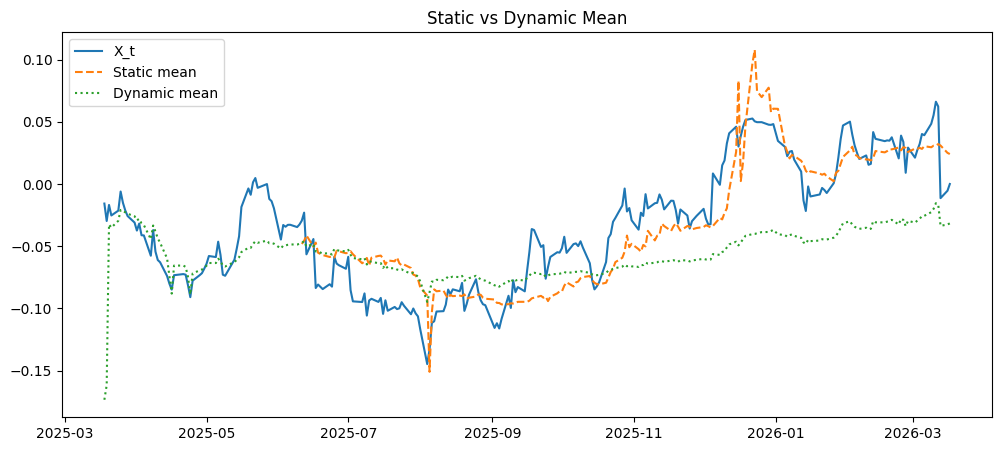

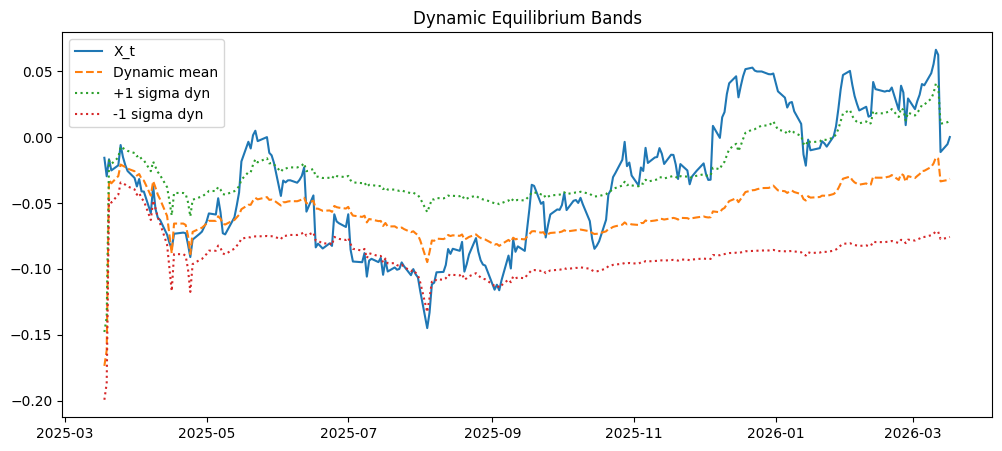

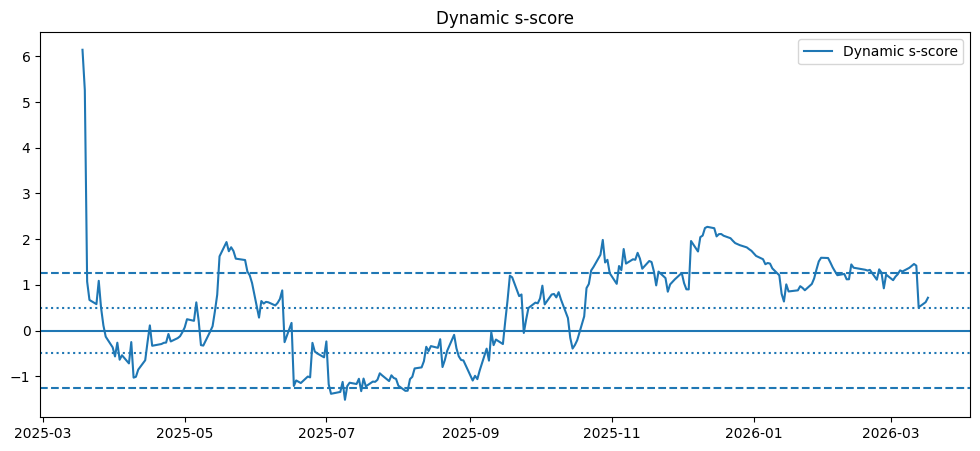

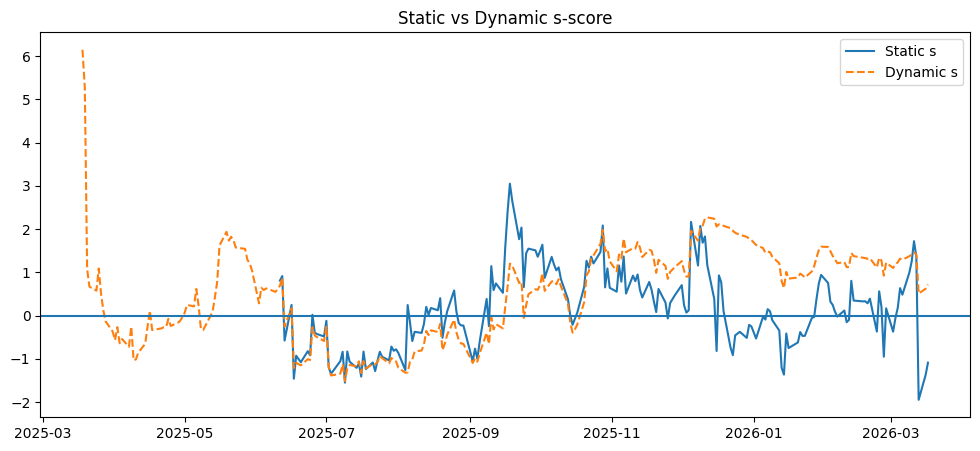

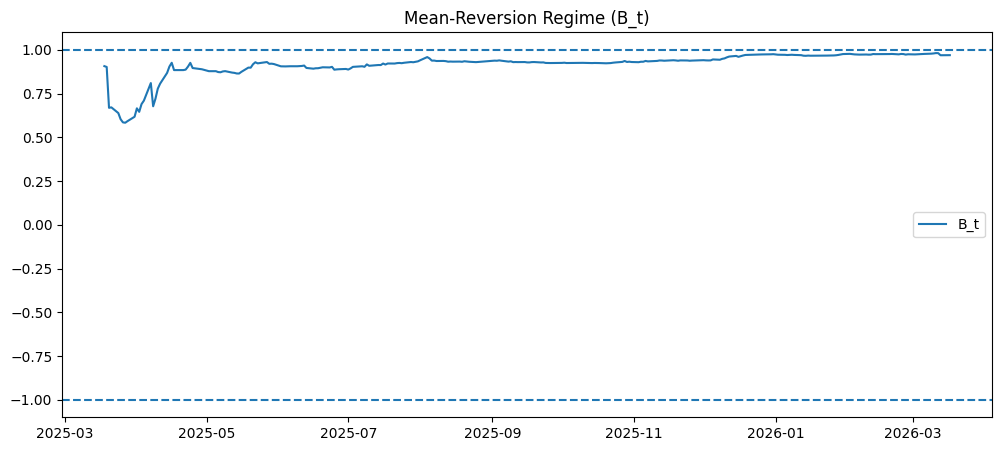

In [21]:
# --------------------------
# Step 12: dynamic mean + dynamic s-score
# --------------------------

# align everything to Kalman index
X_dyn = X_t.reindex(A_t_series.index)

# 1) validity mask (mean reversion regime)
valid_dyn = (
    B_t_series.notna() &
    (np.abs(B_t_series) < 1) &
    (1 - B_t_series**2 > 0)
)

# 2) dynamic equilibrium mean
m_dyn = pd.Series(np.nan, index=B_t_series.index)
m_dyn.loc[valid_dyn] = (
    A_t_series.loc[valid_dyn] /
    (1 - B_t_series.loc[valid_dyn])
)

# 3) use same sigma as static for clean comparison
sigma_const = np.nanmean(sigma_eps_series.values)

sigma_eq_dyn = pd.Series(np.nan, index=B_t_series.index)
sigma_eq_dyn.loc[valid_dyn] = (
    sigma_const /
    np.sqrt(1 - B_t_series.loc[valid_dyn]**2)
)

# 4) dynamic s-score
s_dyn = pd.Series(np.nan, index=B_t_series.index)

valid_s_dyn = valid_dyn & m_dyn.notna() & (sigma_eq_dyn > 0)

s_dyn.loc[valid_s_dyn] = (
    (X_dyn.loc[valid_s_dyn] - m_dyn.loc[valid_s_dyn]) /
    sigma_eq_dyn.loc[valid_s_dyn]
)

# --------------------------
# 5) plots
# --------------------------

# Plot 1: X_t with static + dynamic mean
plt.figure(figsize=(12,5))
plt.plot(X_dyn, label="X_t")
plt.plot(m_series.reindex(X_dyn.index), label="Static mean", linestyle="--")
plt.plot(m_dyn, label="Dynamic mean", linestyle=":")
plt.title("Static vs Dynamic Mean")
plt.legend()
plt.show()

# Plot 2: dynamic bands
upper_dyn = m_dyn + sigma_eq_dyn
lower_dyn = m_dyn - sigma_eq_dyn

plt.figure(figsize=(12,5))
plt.plot(X_dyn, label="X_t")
plt.plot(m_dyn, label="Dynamic mean", linestyle="--")
plt.plot(upper_dyn, linestyle=":", label="+1 sigma dyn")
plt.plot(lower_dyn, linestyle=":", label="-1 sigma dyn")
plt.title("Dynamic Equilibrium Bands")
plt.legend()
plt.show()

# Plot 3: dynamic s-score
plt.figure(figsize=(12,5))
plt.plot(s_dyn, label="Dynamic s-score")
plt.axhline(1.25, linestyle="--")
plt.axhline(-1.25, linestyle="--")
plt.axhline(0.5, linestyle=":")
plt.axhline(-0.5, linestyle=":")
plt.axhline(0)
plt.title("Dynamic s-score")
plt.legend()
plt.show()

# Plot 4: static vs dynamic s-score
plt.figure(figsize=(12,5))
plt.plot(s_static.reindex(s_dyn.index), label="Static s")
plt.plot(s_dyn, label="Dynamic s", linestyle="--")
plt.axhline(0)
plt.title("Static vs Dynamic s-score")
plt.legend()
plt.show()

# Plot 5: B_t regime
plt.figure(figsize=(12,5))
plt.plot(B_t_series, label="B_t")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.title("Mean-Reversion Regime (B_t)")
plt.legend()
plt.show()

===== FORECAST METRICS =====
                Train  Validation      Test
MSE Static   0.000136    0.000128  0.000223
MSE Dynamic  0.000131    0.000127  0.000240
MAE Static   0.008965    0.008131  0.009148
MAE Dynamic  0.008800    0.008190  0.009799

===== EVENT STUDY: STATIC LONG =====
    h  avg_delta  hit_rate  count
0   1    0.00569       1.0      2
1   3        NaN       NaN      0
2   5        NaN       NaN      0
3  10        NaN       NaN      0

===== EVENT STUDY: STATIC SHORT =====
    h  avg_delta  hit_rate  count
0   1  -0.022247  0.666667      3
1   3  -0.066878  1.000000      3
2   5  -0.055361  1.000000      1
3  10        NaN       NaN      0

===== EVENT STUDY: DYNAMIC LONG =====
    h  avg_delta  hit_rate  count
0   1        NaN       NaN      0
1   3        NaN       NaN      0
2   5        NaN       NaN      0
3  10        NaN       NaN      0

===== EVENT STUDY: DYNAMIC SHORT =====
    h  avg_delta  hit_rate  count
0   1  -0.004934  0.619048     21
1   3  -0.011041 

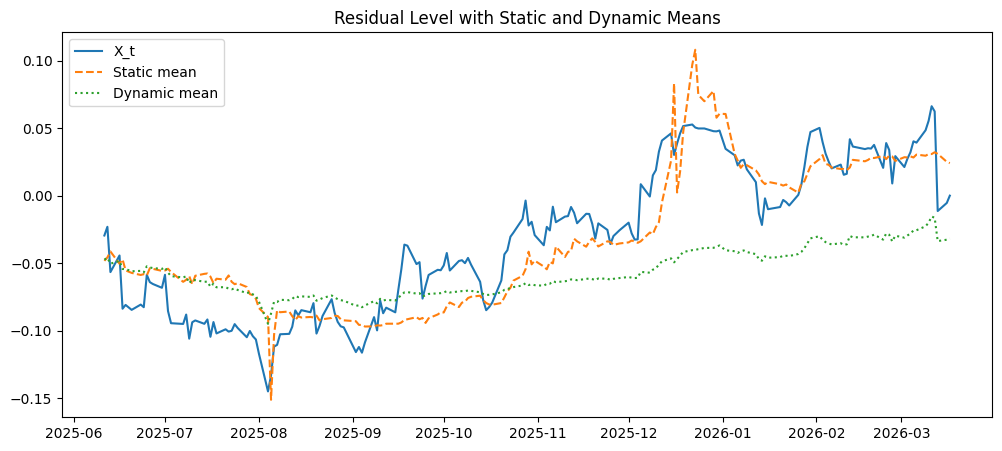

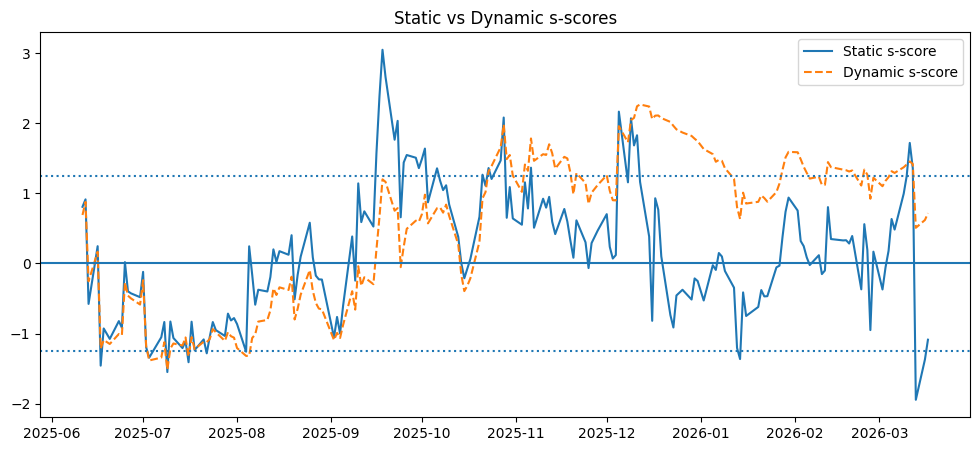

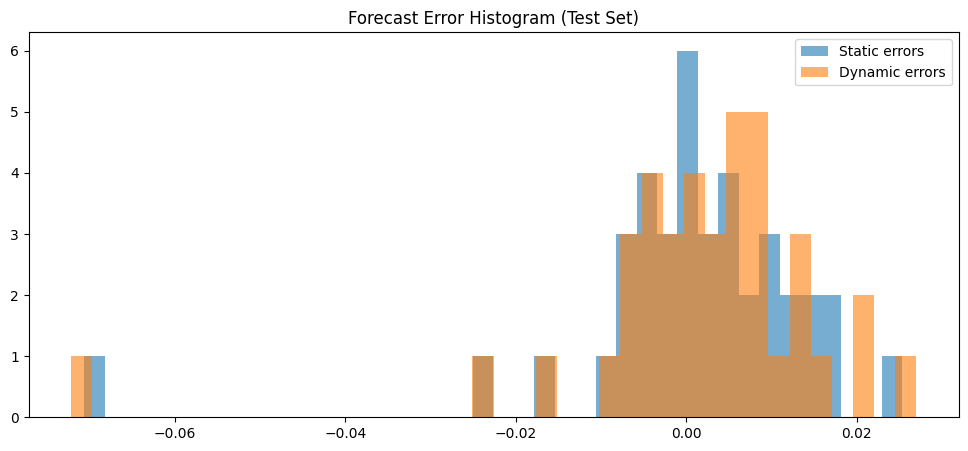

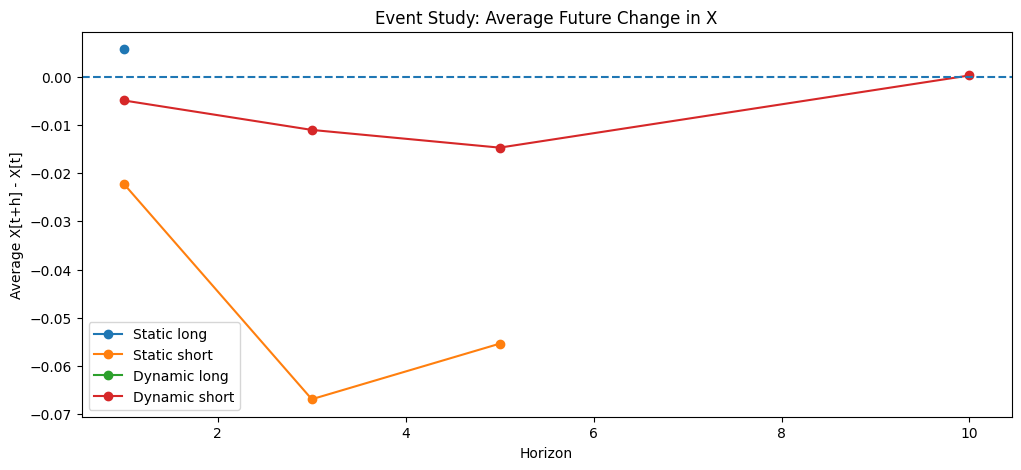

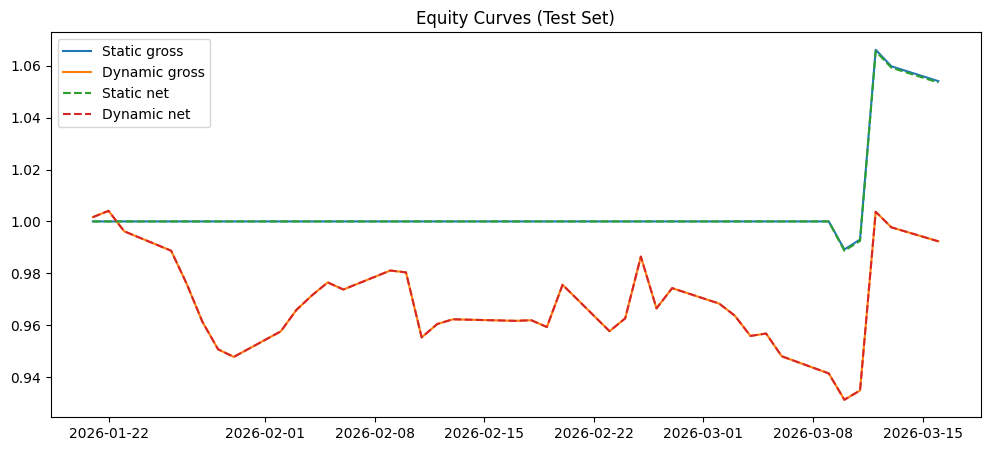

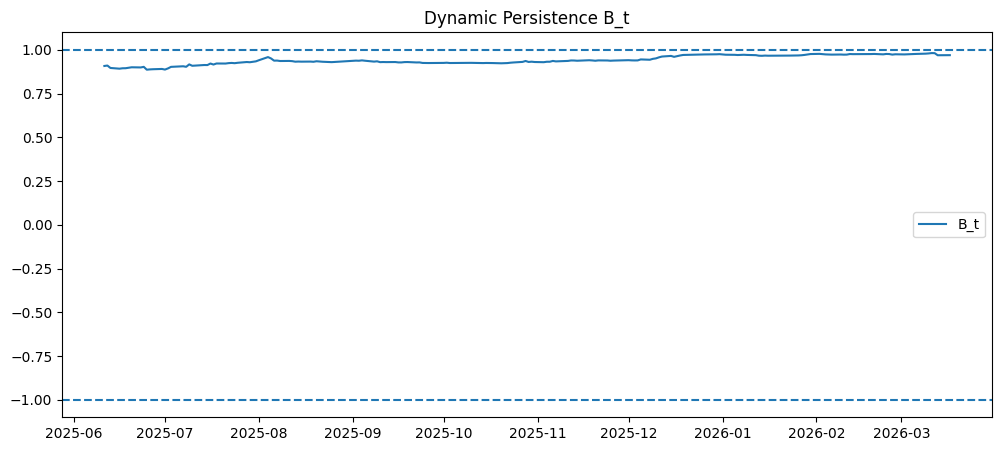

===== HIT RATES =====
    Static Long HitRate  Static Short HitRate  Dynamic Long HitRate  \
h                                                                     
1                   1.0              0.666667                   NaN   
3                   NaN              1.000000                   NaN   
5                   NaN              1.000000                   NaN   
10                  NaN                   NaN                   NaN   

    Dynamic Short HitRate  
h                          
1                0.619048  
3                0.666667  
5                0.789474  
10               0.533333  

===== SIGNAL COUNTS =====
               Static  Dynamic
Long entries        3        1
Short entries       4        1
Exits               6        1

===== FINAL SUMMARY =====
Test MSE Static: 0.00022337310994812045
Test MSE Dynamic: 0.00024028730188350146
Test MAE Static: 0.009147774205252578
Test MAE Dynamic: 0.009799239043172526
Static Net Sharpe: 1.8695775852311043
Dynamic N

In [22]:
# ==========================
# Step 13: compare static vs dynamic
# ==========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# 1) Align all series
# --------------------------
common_index = (
    X_t.index
    .intersection(s_static.dropna().index)
    .intersection(s_dyn.dropna().index)
    .intersection(f_series.index)
    .intersection(c_series.index)
    .intersection(phi_series.index)
    .intersection(B_t_series.index)
    .intersection(resid_raw_series.index)
)

X_cmp = X_t.reindex(common_index)
s_static_cmp = s_static.reindex(common_index)
s_dyn_cmp = s_dyn.reindex(common_index)
c_cmp = c_series.reindex(common_index)
phi_cmp = phi_series.reindex(common_index)
B_cmp = B_t_series.reindex(common_index)
f_dyn_cmp = f_series.reindex(common_index)
resid_ret_cmp = resid_raw_series.reindex(common_index)

# static one-step forecast: c_{t-1} + phi_{t-1} X_{t-1}
f_static_cmp = c_cmp.shift(1) + phi_cmp.shift(1) * X_cmp.shift(1)

# dynamic one-step forecast is already f_t
# align so it forecasts X_t
# f_series from Kalman loop is already for current t using t-1 info

# forecast errors
e_static_cmp = X_cmp - f_static_cmp
e_dyn_cmp = X_cmp - f_dyn_cmp

# valid forecast comparison set
forecast_df = pd.DataFrame({
    "X": X_cmp,
    "f_static": f_static_cmp,
    "f_dyn": f_dyn_cmp,
    "e_static": e_static_cmp,
    "e_dyn": e_dyn_cmp
}).dropna()

# --------------------------
# 2) Train / val / test split
# --------------------------
n = len(forecast_df)
train_end = int(0.60 * n)
val_end = int(0.80 * n)

train_idx = forecast_df.index[:train_end]
val_idx = forecast_df.index[train_end:val_end]
test_idx = forecast_df.index[val_end:]

def mse(x):
    return np.mean(np.square(x))

def mae(x):
    return np.mean(np.abs(x))

forecast_metrics = pd.DataFrame({
    "Train": [
        mse(forecast_df.loc[train_idx, "e_static"]),
        mse(forecast_df.loc[train_idx, "e_dyn"]),
        mae(forecast_df.loc[train_idx, "e_static"]),
        mae(forecast_df.loc[train_idx, "e_dyn"]),
    ],
    "Validation": [
        mse(forecast_df.loc[val_idx, "e_static"]),
        mse(forecast_df.loc[val_idx, "e_dyn"]),
        mae(forecast_df.loc[val_idx, "e_static"]),
        mae(forecast_df.loc[val_idx, "e_dyn"]),
    ],
    "Test": [
        mse(forecast_df.loc[test_idx, "e_static"]),
        mse(forecast_df.loc[test_idx, "e_dyn"]),
        mae(forecast_df.loc[test_idx, "e_static"]),
        mae(forecast_df.loc[test_idx, "e_dyn"]),
    ]
}, index=["MSE Static", "MSE Dynamic", "MAE Static", "MAE Dynamic"])

print("===== FORECAST METRICS =====")
print(forecast_metrics)
print()

# --------------------------
# 3) Entry events + event study
# --------------------------
entry_thr = 1.25
exit_thr = 0.50
horizons = [1, 3, 5, 10]

def get_entry_dates(signal, side, threshold=1.25):
    if side == "long":
        return signal.index[signal < -threshold]
    elif side == "short":
        return signal.index[signal > threshold]
    else:
        raise ValueError("side must be 'long' or 'short'")

def event_study(X_series, entry_dates, horizons, side):
    rows = []
    for h in horizons:
        vals = []
        hits = []
        for dt in entry_dates:
            if dt not in X_series.index:
                continue
            loc = X_series.index.get_loc(dt)
            if loc + h >= len(X_series):
                continue
            delta = X_series.iloc[loc + h] - X_series.iloc[loc]
            vals.append(delta)
            if side == "long":
                hits.append(delta > 0)
            else:
                hits.append(delta < 0)
        rows.append({
            "h": h,
            "avg_delta": np.mean(vals) if len(vals) > 0 else np.nan,
            "hit_rate": np.mean(hits) if len(hits) > 0 else np.nan,
            "count": len(vals)
        })
    return pd.DataFrame(rows)

# use TEST only for final comparison
X_test = X_cmp.reindex(test_idx)
s_static_test = s_static_cmp.reindex(test_idx)
s_dyn_test = s_dyn_cmp.reindex(test_idx)

static_long_dates = get_entry_dates(s_static_test.dropna(), "long", entry_thr)
static_short_dates = get_entry_dates(s_static_test.dropna(), "short", entry_thr)
dyn_long_dates = get_entry_dates(s_dyn_test.dropna(), "long", entry_thr)
dyn_short_dates = get_entry_dates(s_dyn_test.dropna(), "short", entry_thr)

static_long_es = event_study(X_test, static_long_dates, horizons, "long")
static_short_es = event_study(X_test, static_short_dates, horizons, "short")
dyn_long_es = event_study(X_test, dyn_long_dates, horizons, "long")
dyn_short_es = event_study(X_test, dyn_short_dates, horizons, "short")

print("===== EVENT STUDY: STATIC LONG =====")
print(static_long_es)
print()
print("===== EVENT STUDY: STATIC SHORT =====")
print(static_short_es)
print()
print("===== EVENT STUDY: DYNAMIC LONG =====")
print(dyn_long_es)
print()
print("===== EVENT STUDY: DYNAMIC SHORT =====")
print(dyn_short_es)
print()

# --------------------------
# 4) Same trading rule for both
# --------------------------
def build_positions(signal, entry_thr=1.25, exit_thr=0.50, mr_flag=None):
    pos = 0
    positions = []
    long_entries = []
    short_entries = []
    exits = []

    for dt in signal.index:
        s = signal.loc[dt]
        mr_ok = True if mr_flag is None else bool(mr_flag.loc[dt])

        if pd.isna(s) or not mr_ok:
            if pos != 0:
                pos = 0
                exits.append(dt)
            positions.append(pos)
            continue

        if pos == 0:
            if s < -entry_thr:
                pos = 1
                long_entries.append(dt)
            elif s > entry_thr:
                pos = -1
                short_entries.append(dt)

        elif pos == 1:
            if abs(s) < exit_thr:
                pos = 0
                exits.append(dt)

        elif pos == -1:
            if abs(s) < exit_thr:
                pos = 0
                exits.append(dt)

        positions.append(pos)

    return (
        pd.Series(positions, index=signal.index),
        long_entries,
        short_entries,
        exits
    )

mr_flag_dyn = (np.abs(B_cmp.reindex(common_index)) < 1)

pos_static, static_longs, static_shorts, static_exits = build_positions(
    s_static_cmp.reindex(common_index), entry_thr, exit_thr
)

pos_dyn, dyn_longs, dyn_shorts, dyn_exits = build_positions(
    s_dyn_cmp.reindex(common_index), entry_thr, exit_thr, mr_flag=mr_flag_dyn.reindex(common_index)
)

# --------------------------
# 5) Strategy returns
# --------------------------
# Use next-period residual return
resid_next = resid_ret_cmp.shift(-1).reindex(common_index)

gross_static = pos_static * resid_next
gross_dyn = pos_dyn * resid_next

tcost = 0.0005  # 5 bps per unit turnover
net_static = gross_static - tcost * pos_static.diff().abs().fillna(0)
net_dyn = gross_dyn - tcost * pos_dyn.diff().abs().fillna(0)

# test set only
gross_static_test = gross_static.reindex(test_idx).dropna()
gross_dyn_test = gross_dyn.reindex(test_idx).dropna()
net_static_test = net_static.reindex(test_idx).dropna()
net_dyn_test = net_dyn.reindex(test_idx).dropna()
pos_static_test = pos_static.reindex(test_idx).fillna(0)
pos_dyn_test = pos_dyn.reindex(test_idx).fillna(0)

def max_drawdown(ret_series):
    eq = (1 + ret_series).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1
    return dd.min()

def perf_metrics(ret_series, pos_series):
    if len(ret_series) == 0 or ret_series.std(ddof=1) == 0:
        return {
            "mean": np.nan,
            "vol": np.nan,
            "sharpe_ann": np.nan,
            "cum_return": np.nan,
            "max_dd": np.nan,
            "turnover": np.nan,
            "n_days": len(ret_series)
        }
    return {
        "mean": ret_series.mean(),
        "vol": ret_series.std(ddof=1),
        "sharpe_ann": np.sqrt(252) * ret_series.mean() / ret_series.std(ddof=1),
        "cum_return": (1 + ret_series).prod() - 1,
        "max_dd": max_drawdown(ret_series),
        "turnover": pos_series.diff().abs().fillna(0).sum(),
        "n_days": len(ret_series)
    }

perf_table = pd.DataFrame({
    "Static Gross": perf_metrics(gross_static_test, pos_static_test),
    "Dynamic Gross": perf_metrics(gross_dyn_test, pos_dyn_test),
    "Static Net": perf_metrics(net_static_test, pos_static_test),
    "Dynamic Net": perf_metrics(net_dyn_test, pos_dyn_test),
})

print("===== PERFORMANCE (TEST SET) =====")
print(perf_table)
print()

# --------------------------
# 6) Core plots
# --------------------------

# Plot 1: residual level with both means
plt.figure(figsize=(12, 5))
plt.plot(X_cmp, label="X_t")
plt.plot(m_series.reindex(X_cmp.index), label="Static mean", linestyle="--")
plt.plot(m_dyn.reindex(X_cmp.index), label="Dynamic mean", linestyle=":")
plt.title("Residual Level with Static and Dynamic Means")
plt.legend()
plt.show()

# Plot 2: static vs dynamic s-scores
plt.figure(figsize=(12, 5))
plt.plot(s_static_cmp.reindex(common_index), label="Static s-score")
plt.plot(s_dyn_cmp.reindex(common_index), label="Dynamic s-score", linestyle="--")
plt.axhline(entry_thr, linestyle=":")
plt.axhline(-entry_thr, linestyle=":")
plt.axhline(0, linestyle="-")
plt.title("Static vs Dynamic s-scores")
plt.legend()
plt.show()

# Plot 3: forecast error histograms
plt.figure(figsize=(12, 5))
plt.hist(forecast_df.loc[test_idx, "e_static"], bins=40, alpha=0.6, label="Static errors")
plt.hist(forecast_df.loc[test_idx, "e_dyn"], bins=40, alpha=0.6, label="Dynamic errors")
plt.title("Forecast Error Histogram (Test Set)")
plt.legend()
plt.show()

# Plot 4: event study average future delta
plt.figure(figsize=(12, 5))
plt.plot(static_long_es["h"], static_long_es["avg_delta"], marker="o", label="Static long")
plt.plot(static_short_es["h"], static_short_es["avg_delta"], marker="o", label="Static short")
plt.plot(dyn_long_es["h"], dyn_long_es["avg_delta"], marker="o", label="Dynamic long")
plt.plot(dyn_short_es["h"], dyn_short_es["avg_delta"], marker="o", label="Dynamic short")
plt.axhline(0, linestyle="--")
plt.title("Event Study: Average Future Change in X")
plt.xlabel("Horizon")
plt.ylabel("Average X[t+h] - X[t]")
plt.legend()
plt.show()

# Plot 5: equity curves
eq_static_gross = (1 + gross_static_test).cumprod()
eq_dyn_gross = (1 + gross_dyn_test).cumprod()
eq_static_net = (1 + net_static_test).cumprod()
eq_dyn_net = (1 + net_dyn_test).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(eq_static_gross, label="Static gross")
plt.plot(eq_dyn_gross, label="Dynamic gross")
plt.plot(eq_static_net, label="Static net", linestyle="--")
plt.plot(eq_dyn_net, label="Dynamic net", linestyle="--")
plt.title("Equity Curves (Test Set)")
plt.legend()
plt.show()

# Plot 6: dynamic persistence
plt.figure(figsize=(12, 5))
plt.plot(B_cmp.reindex(common_index), label="B_t")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.title("Dynamic Persistence B_t")
plt.legend()
plt.show()

# --------------------------
# 7) Hit-rate summary table
# --------------------------
hitrate_table = pd.DataFrame({
    "Static Long HitRate": static_long_es.set_index("h")["hit_rate"],
    "Static Short HitRate": static_short_es.set_index("h")["hit_rate"],
    "Dynamic Long HitRate": dyn_long_es.set_index("h")["hit_rate"],
    "Dynamic Short HitRate": dyn_short_es.set_index("h")["hit_rate"],
})

print("===== HIT RATES =====")
print(hitrate_table)
print()

# --------------------------
# 8) Signal counts
# --------------------------
signal_counts = pd.DataFrame({
    "Static": [len(static_longs), len(static_shorts), len(static_exits)],
    "Dynamic": [len(dyn_longs), len(dyn_shorts), len(dyn_exits)]
}, index=["Long entries", "Short entries", "Exits"])

print("===== SIGNAL COUNTS =====")
print(signal_counts)
print()

# --------------------------
# 9) Final compact summary
# --------------------------
summary = {
    "Test MSE Static": mse(forecast_df.loc[test_idx, "e_static"]),
    "Test MSE Dynamic": mse(forecast_df.loc[test_idx, "e_dyn"]),
    "Test MAE Static": mae(forecast_df.loc[test_idx, "e_static"]),
    "Test MAE Dynamic": mae(forecast_df.loc[test_idx, "e_dyn"]),
    "Static Net Sharpe": perf_table.loc["sharpe_ann", "Static Net"],
    "Dynamic Net Sharpe": perf_table.loc["sharpe_ann", "Dynamic Net"],
    "Static Turnover": perf_table.loc["turnover", "Static Net"],
    "Dynamic Turnover": perf_table.loc["turnover", "Dynamic Net"],
}

print("===== FINAL SUMMARY =====")
for k, v in summary.items():
    print(f"{k}: {v}")